# SFT Telemetry Decision Notebook

Этот notebook нужен не для красивого отчёта, а для решения:

1. какие `label` усиливать в dense dataset;
2. какие `source + label` усиливать или резать;
3. где модель ошибается: `cot`, `format`, `final_answer`, `boxed_answer`;
4. какие параметры поставить в `dense.label_weights` и multipliers.

## Главная логика

- **Train telemetry** показывает, что модель тяжело воспроизводит во время обучения.
- **Eval telemetry** показывает, что плохо обобщается на unseen validation.
- **Bad tokens** показывают, проблема в задаче, в CoT, в формате или в самом boxed answer.
- **Dense dataset** лучше строить не по одному loss, а по пересечению `eval hard + answer hard + train hard`, с ручными весами.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 260)
pd.set_option("display.width", 260)


## 1. Paths

Если notebook лежит в папке `notebooks/`, оставь `PROJECT_ROOT = Path("..")`.

Если запускаешь из корня проекта, поставь:

```python
PROJECT_ROOT = Path(".")
```


In [2]:
PROJECT_ROOT = Path("..")

MODEL_DIR = PROJECT_ROOT / "models/sft_v0.0.23"

TRAIN_CSV = PROJECT_ROOT / "data/generated/train_with_syntetic.csv"
VAL_CSV = PROJECT_ROOT / "data/prepared/val_stratified.csv"

TRAIN_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_train_telemetry_analysis")
EVAL_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_eval_telemetry_analysis")

# fallback для старого single analysis dir
if not TRAIN_ANALYSIS_DIR.exists():
    fallback = Path(str(MODEL_DIR) + "_telemetry_analysis")
    if fallback.exists():
        TRAIN_ANALYSIS_DIR = fallback

TRAIN_TELEMETRY_DIR = MODEL_DIR / "train_telemetry"
EVAL_TELEMETRY_DIR = MODEL_DIR / "eval_telemetry"

print("MODEL_DIR:", MODEL_DIR, "exists=", MODEL_DIR.exists())
print("TRAIN_ANALYSIS_DIR:", TRAIN_ANALYSIS_DIR, "exists=", TRAIN_ANALYSIS_DIR.exists())
print("EVAL_ANALYSIS_DIR:", EVAL_ANALYSIS_DIR, "exists=", EVAL_ANALYSIS_DIR.exists())
print("TRAIN_TELEMETRY_DIR:", TRAIN_TELEMETRY_DIR, "exists=", TRAIN_TELEMETRY_DIR.exists())
print("EVAL_TELEMETRY_DIR:", EVAL_TELEMETRY_DIR, "exists=", EVAL_TELEMETRY_DIR.exists())
print("TRAIN_CSV:", TRAIN_CSV, "exists=", TRAIN_CSV.exists())
print("VAL_CSV:", VAL_CSV, "exists=", VAL_CSV.exists())


MODEL_DIR: ../models/sft_v0.0.23 exists= True
TRAIN_ANALYSIS_DIR: ../models/sft_v0.0.23_train_telemetry_analysis exists= True
EVAL_ANALYSIS_DIR: ../models/sft_v0.0.23_eval_telemetry_analysis exists= True
TRAIN_TELEMETRY_DIR: ../models/sft_v0.0.23/train_telemetry exists= True
EVAL_TELEMETRY_DIR: ../models/sft_v0.0.23/eval_telemetry exists= True
TRAIN_CSV: ../data/generated/train_with_syntetic.csv exists= True
VAL_CSV: ../data/prepared/val_stratified.csv exists= True


## 2. Load reports

In [3]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print("Missing:", path)
    return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    print("Missing:", path)
    return {}

def load_analysis(analysis_dir: Path) -> dict:
    return {
        "summary": read_json_if_exists(analysis_dir / "00_input_summary.json"),
        "by_label": read_csv_if_exists(analysis_dir / "01_by_label.csv"),
        "by_source_label": read_csv_if_exists(analysis_dir / "02_by_source_label.csv"),
        "hard_examples": read_csv_if_exists(analysis_dir / "03_hard_examples.csv"),
        "bad_tokens": read_csv_if_exists(analysis_dir / "04_bad_tokens.csv"),
    }

train = load_analysis(TRAIN_ANALYSIS_DIR)
eval_ = load_analysis(EVAL_ANALYSIS_DIR)

train_df = pd.read_csv(TRAIN_CSV) if TRAIN_CSV.exists() else pd.DataFrame()
val_df = pd.read_csv(VAL_CSV) if VAL_CSV.exists() else pd.DataFrame()

print("train by_label rows:", len(train["by_label"]))
print("eval by_label rows:", len(eval_["by_label"]))
print("train rows:", len(train_df))
print("val rows:", len(val_df))


train by_label rows: 17
eval by_label rows: 7
train rows: 20510
val rows: 950


## 3. Metric thresholds

Эти границы не абсолютная истина, но они дают нормальную шкалу.

### `mean_nll`
Средняя ошибка по target tokens.

| Значение | Интерпретация |
|---:|---|
| `< 0.02` | почти выучено |
| `0.02–0.08` | нормальная/средняя сложность |
| `0.08–0.18` | hard |
| `> 0.18` | very hard |

### `hard_token_ratio`
Доля токенов с `logprob < -1.0`, то есть модель дала target token probability меньше `e^-1 ≈ 36.8%`.

| Значение | Интерпретация |
|---:|---|
| `< 0.01` | почти нет плохих токенов |
| `0.01–0.02` | немного плохих токенов |
| `0.02–0.08` | hard |
| `> 0.08` | very hard |

### `near_zero_token_ratio`
Доля токенов с `logprob > -0.05`, то есть probability target token примерно больше `95%`.

| Значение | Интерпретация |
|---:|---|
| `> 0.97` | почти заучено |
| `0.90–0.97` | нормально |
| `< 0.90` | много неуверенных токенов |

### `boxed_answer_mean_nll`
Ошибка именно по ответу внутри `\boxed{...}`.

| Значение | Интерпретация |
|---:|---|
| `< 0.02` | answer почти выучен |
| `0.02–0.08` | medium |
| `0.08–0.15` | answer hard |
| `> 0.15` | answer very hard |

### Что реально важно для dense
- `eval_boxed_answer_mean_nll` высокий → усиливать.
- `eval_difficulty_score` высокий → плохо обобщается, усиливать label/source.
- `train hard`, но `eval easy` → возможно формат/CoT, не дублировать вслепую.
- `format_mean_nll` высокий или bad tokens в `format` → чинить шаблон/CoT, не только дублировать.


In [4]:
def level_mean_nll(x):
    if pd.isna(x): return "unknown"
    if x < 0.02: return "easy"
    if x < 0.08: return "medium"
    if x < 0.18: return "hard"
    return "very_hard"

def level_hard_ratio(x):
    if pd.isna(x): return "unknown"
    if x < 0.01: return "easy"
    if x < 0.02: return "medium"
    if x < 0.08: return "hard"
    return "very_hard"

def level_near_zero(x):
    if pd.isna(x): return "unknown"
    if x > 0.97: return "almost_memorized"
    if x > 0.90: return "normal"
    return "not_learned"

def level_boxed_nll(x):
    if pd.isna(x): return "unknown"
    if x < 0.02: return "answer_easy"
    if x < 0.08: return "answer_medium"
    if x < 0.15: return "answer_hard"
    return "answer_very_hard"


## 4. Sanity check

In [5]:
print("TRAIN SUMMARY")
display(pd.DataFrame([train["summary"]]))

print("EVAL SUMMARY")
display(pd.DataFrame([eval_["summary"]]))

def sanity_notes(summary, name):
    if not summary:
        print(name, "summary missing")
        return

    print(f"\n{name} notes:")
    print("telemetry files:", summary.get("telemetry_files_count"))
    print("raw records:", summary.get("raw_records_count"))
    print("unique ids:", summary.get("unique_ids_raw"))
    print("unknown source:", summary.get("unknown_source_count"))
    print("unknown label:", summary.get("unknown_label_count"))
    print("zero loss tokens:", summary.get("zero_loss_tokens_count"))
    print("checkpoint buckets:", summary.get("checkpoint_buckets"))

sanity_notes(train["summary"], "TRAIN")
sanity_notes(eval_["summary"], "EVAL")


TRAIN SUMMARY


,telemetry_files_count,telemetry_files,raw_records_count,latest_records_count,unique_ids_raw,unique_ids_latest,unknown_source_count,unknown_label_count,zero_loss_tokens_count,checkpoint_buckets
0,3,"[models/sft_v0.0.23/train_telemetry/train_until_checkpoint-320_rank-0.jsonl, models/sft_v0.0.23/train_telemetry/train_until_checkpoint-640_rank-0.jsonl, models/sft_v0.0.23/train_telemetry/train_until_checkpoint-960_rank-0.jsonl]",20510,20634,20464,20464,0,0,0,"[320, 640, 960]"


EVAL SUMMARY


,telemetry_files_count,telemetry_files,raw_records_count,latest_records_count,unique_ids_raw,unique_ids_latest,unknown_source_count,unknown_label_count,zero_loss_tokens_count,checkpoint_buckets
0,2,"[models/sft_v0.0.23/eval_telemetry/eval_at_checkpoint-320_rank-0.jsonl, models/sft_v0.0.23/eval_telemetry/eval_at_checkpoint-640_rank-0.jsonl]",1670,1670,835,835,0,0,0,"[320, 640]"



TRAIN notes:
telemetry files: 3
raw records: 20510
unique ids: 20464
unknown source: 0
unknown label: 0
zero loss tokens: 0
checkpoint buckets: [320, 640, 960]

EVAL notes:
telemetry files: 2
raw records: 1670
unique ids: 835
unknown source: 0
unknown label: 0
zero loss tokens: 0
checkpoint buckets: [320, 640]


Если `unknown_source_count`, `unknown_label_count` или `zero_loss_tokens_count` не равны нулю — сначала чинить telemetry, потом делать выводы.


## 5. Train vs Eval by label

In [6]:
def prepare_by_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p50_mean_nll", "p95_mean_nll",
        "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "final_answer_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c != "label"})
    return out

train_label = prepare_by_label(train["by_label"], "train")
eval_label = prepare_by_label(eval_["by_label"], "eval")

if not train_label.empty and not eval_label.empty:
    label_cmp = train_label.merge(eval_label, on="label", how="outer")
elif not train_label.empty:
    label_cmp = train_label.copy()
else:
    label_cmp = eval_label.copy()

if not label_cmp.empty:
    label_cmp["decision_score"] = (
        label_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + label_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + label_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + label_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )

    for prefix in ["train", "eval"]:
        if f"{prefix}_mean_nll" in label_cmp.columns:
            label_cmp[f"{prefix}_mean_nll_level"] = label_cmp[f"{prefix}_mean_nll"].apply(level_mean_nll)
        if f"{prefix}_hard_token_ratio" in label_cmp.columns:
            label_cmp[f"{prefix}_hard_token_ratio_level"] = label_cmp[f"{prefix}_hard_token_ratio"].apply(level_hard_ratio)
        if f"{prefix}_near_zero_token_ratio" in label_cmp.columns:
            label_cmp[f"{prefix}_near_zero_level"] = label_cmp[f"{prefix}_near_zero_token_ratio"].apply(level_near_zero)
        if f"{prefix}_boxed_answer_mean_nll" in label_cmp.columns:
            label_cmp[f"{prefix}_boxed_answer_level"] = label_cmp[f"{prefix}_boxed_answer_mean_nll"].apply(level_boxed_nll)

    label_cmp = label_cmp.sort_values("decision_score", ascending=False)

display(label_cmp)


,label,train_count,train_unique_ids,train_difficulty_score,train_mean_nll,train_p50_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p50_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,decision_score,train_mean_nll_level,train_hard_token_ratio_level,train_near_zero_level,train_boxed_answer_level,eval_mean_nll_level,eval_hard_token_ratio_level,eval_near_zero_level,eval_boxed_answer_level
16,unit conversion,1435,1435,0.562431,0.200074,0.152173,0.390734,0.071689,0.848034,NaN,0.029282,0.001139,0.211156,0.001139,0.0,0.287075,1.000000,0.696167,0.000000,318.0,159.0,0.418245,0.139259,0.139251,0.191263,0.054260,0.879456,NaN,0.002227,0.001061,0.147831,0.001061,0.0,0.205480,1.0000,0.54717,0.000000,2.901042,very_hard,hard,not_learned,answer_easy,hard,hard,not_learned,answer_easy
5,cryptarithm,550,550,0.409932,0.211606,0.077445,1.058369,0.049788,0.860325,NaN,0.089066,0.222991,0.221172,0.275038,0.0,0.273339,0.650909,0.361818,0.009091,16.0,8.0,0.084528,0.057883,0.051725,0.111467,0.015072,0.930642,NaN,0.011304,0.087483,0.061461,0.129150,0.0,0.076843,0.4375,0.12500,0.000000,1.410204,very_hard,hard,not_learned,answer_very_hard,medium,medium,normal,answer_hard
3,bit_tail_repair,137,137,0.624004,0.261020,0.183362,1.041045,0.085126,0.821633,NaN,0.040310,NaN,0.270711,0.000000,0.0,0.359368,0.948905,0.671533,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.624004,very_hard,very_hard,not_learned,unknown,unknown,unknown,unknown,unknown
2,bit_tail_completion,74,74,0.445048,0.191281,0.116808,0.969022,0.059888,0.855879,NaN,0.029310,NaN,0.197494,0.000000,0.0,0.259462,0.824324,0.378378,0.013514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.445048,very_hard,hard,not_learned,unknown,unknown,unknown,unknown,unknown
7,encryption_apply_mapping_to_target_partial,987,987,0.245224,0.149330,0.043575,0.634423,0.034423,0.926228,NaN,0.032996,0.002202,0.179303,0.002202,0.0,0.221013,0.434650,0.146910,0.133739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.245224,hard,hard,normal,answer_easy,unknown,unknown,unknown,unknown
15,numeral equations_rule_application,1338,1335,0.152186,0.071707,0.001371,0.570820,0.014152,0.966083,NaN,0.033384,0.004816,0.077030,0.004809,0.0,0.092510,0.074738,0.062780,0.893871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.152186,medium,medium,normal,answer_easy,unknown,unknown,unknown,unknown
13,numeral equations,510,510,0.138090,0.062171,0.001714,0.480102,0.014267,0.971789,NaN,0.031733,0.000894,0.062508,0.000890,0.0,0.076859,0.078431,0.068627,0.901961,106.0,53.0,0.005043,0.002534,0.001626,0.007126,0.000276,0.998901,NaN,0.000439,0.001217,0.002546,0.001217,0.0,0.002825,0.0000,0.00000,1.000000,0.150610,medium,medium,almost_memorized,answer_easy,easy,easy,almost_memorized,answer_easy
9,encryption_new_mapping_from_completed_word,1274,1274,0.129113,0.068055,0.002021,0.148689,0.014527,0.965632,NaN,0.034516,0.010283,0.079928,0.013808,0.0,0.097331,0.069859,0.050235,0.835165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129113,medium,medium,normal,answer_easy,unknown,unknown,unknown,unknown
12,gravitational,1437,1437,0.077622,0.053460,0.032110,0.087939,0.017682,0.965753,NaN,0.032151,0.001415,0.054270,0.001415,0.0,0.072323,0.054976,0.045929,0.002784,320.0,160.0,0.022385,0.030498,0.030496,0.036992,0.011624,0.978684,NaN,0.001997,0.001879,0.0312

### Как читать таблицу label

Ищи не просто верхнюю строку, а паттерн:

| Паттерн | Решение |
|---|---|
| `eval hard` + `boxed_answer hard` | усиливать label |
| `train hard` + `eval easy` | проверить bad tokens; возможно CoT/format |
| `train easy` + `eval hard` | не хватает diversity, нужны новые примеры |
| `train easy` + `eval easy` | downsample |
| `format hard` | чинить формат/trace, а не дублировать вслепую |


## 6. Label visualizations

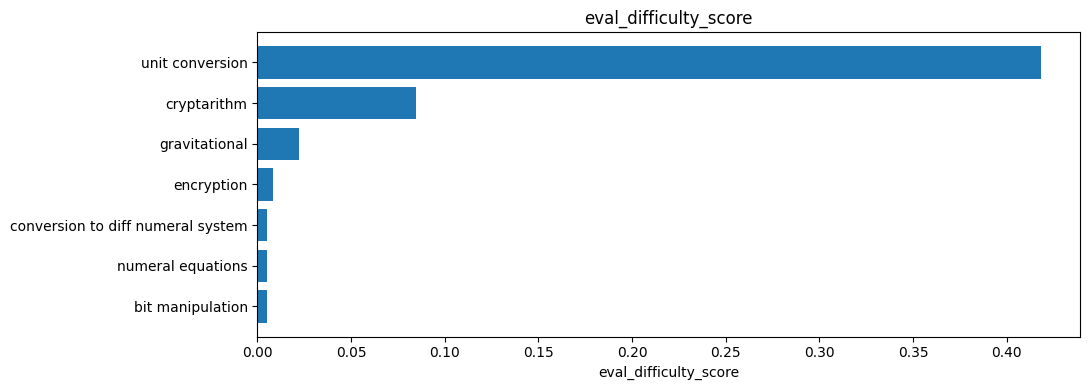

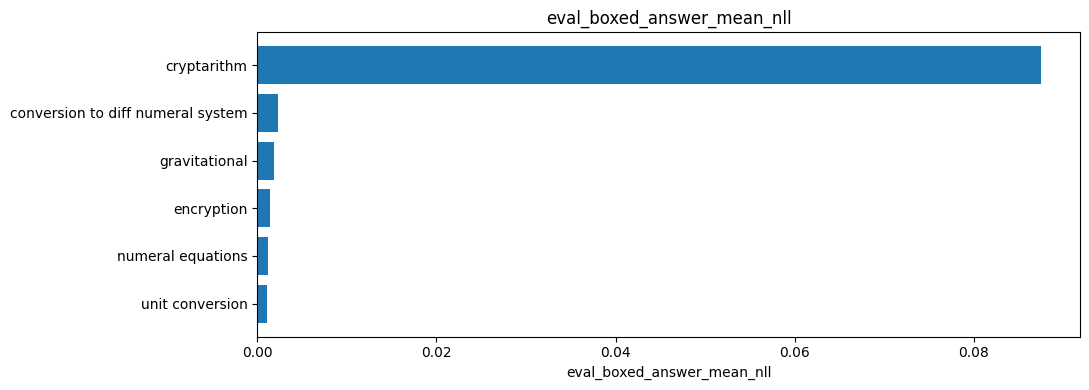

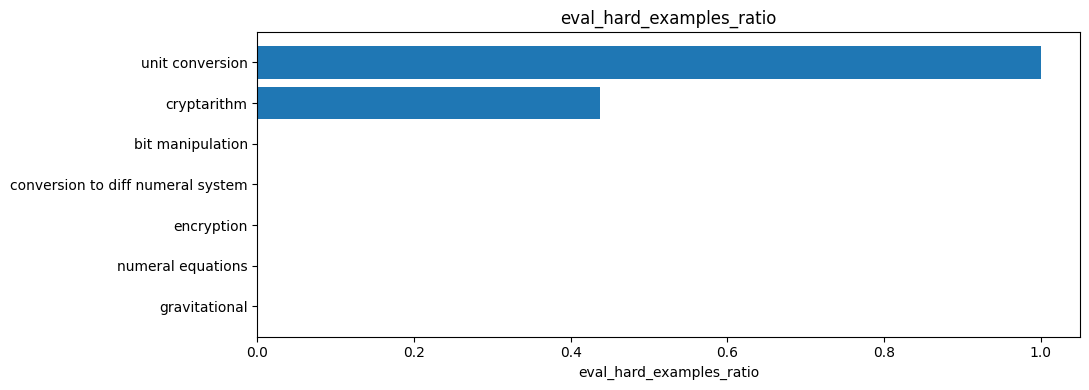

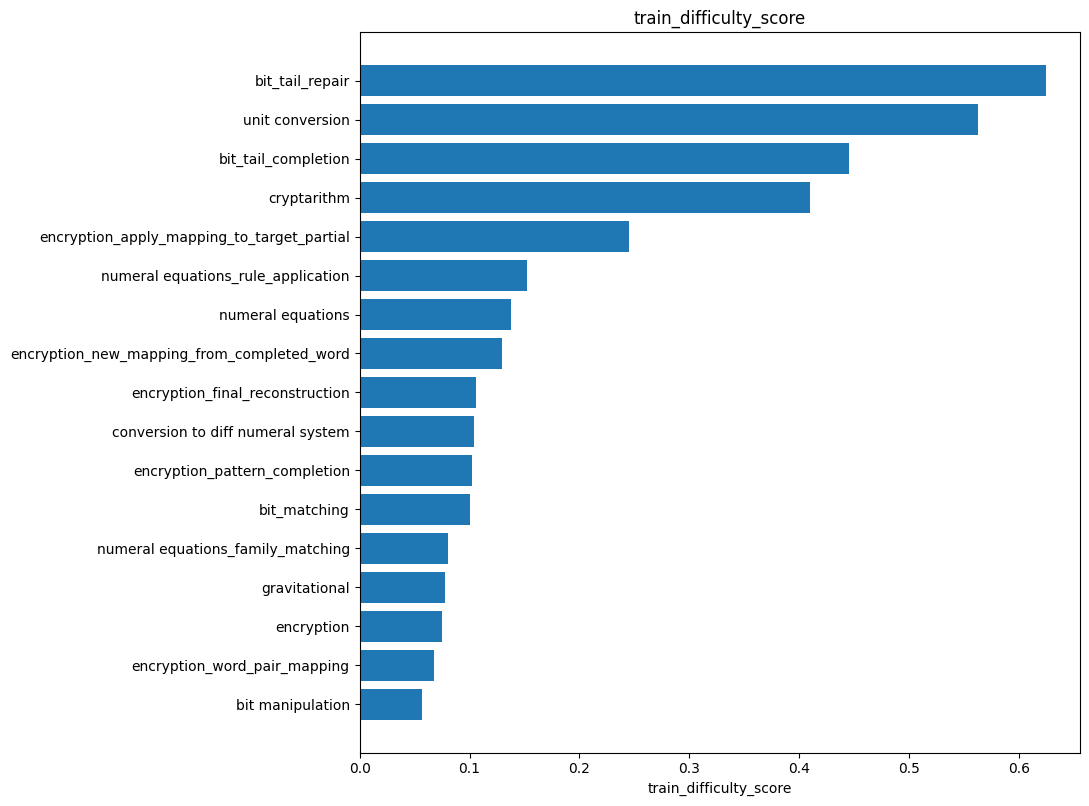

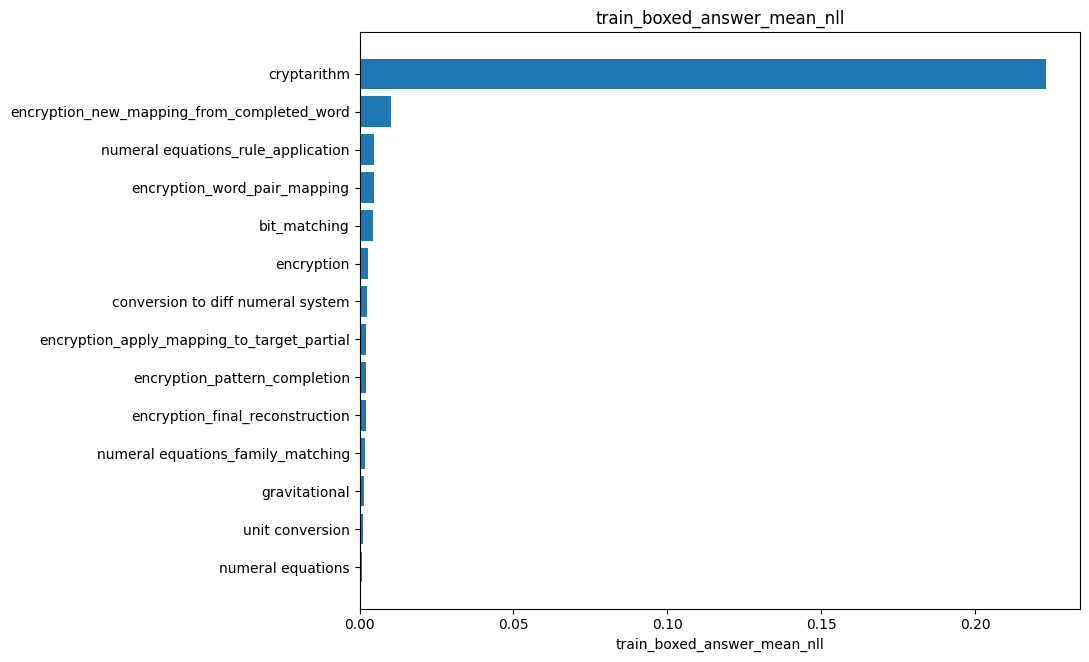

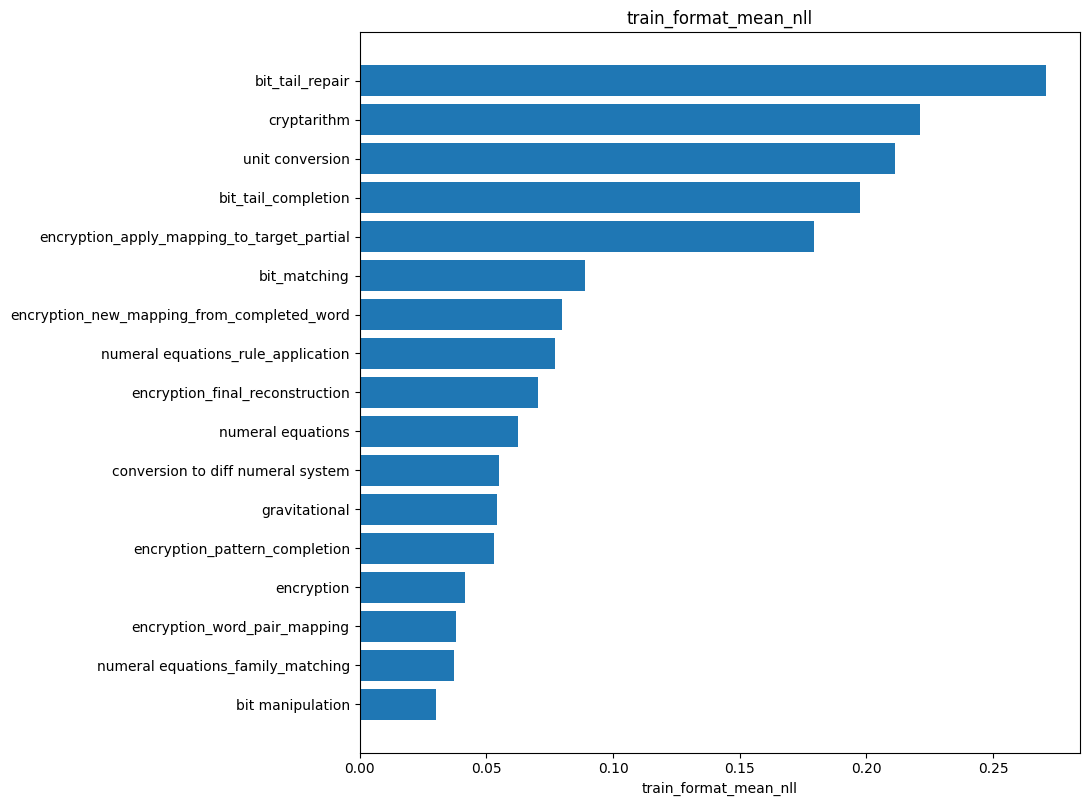

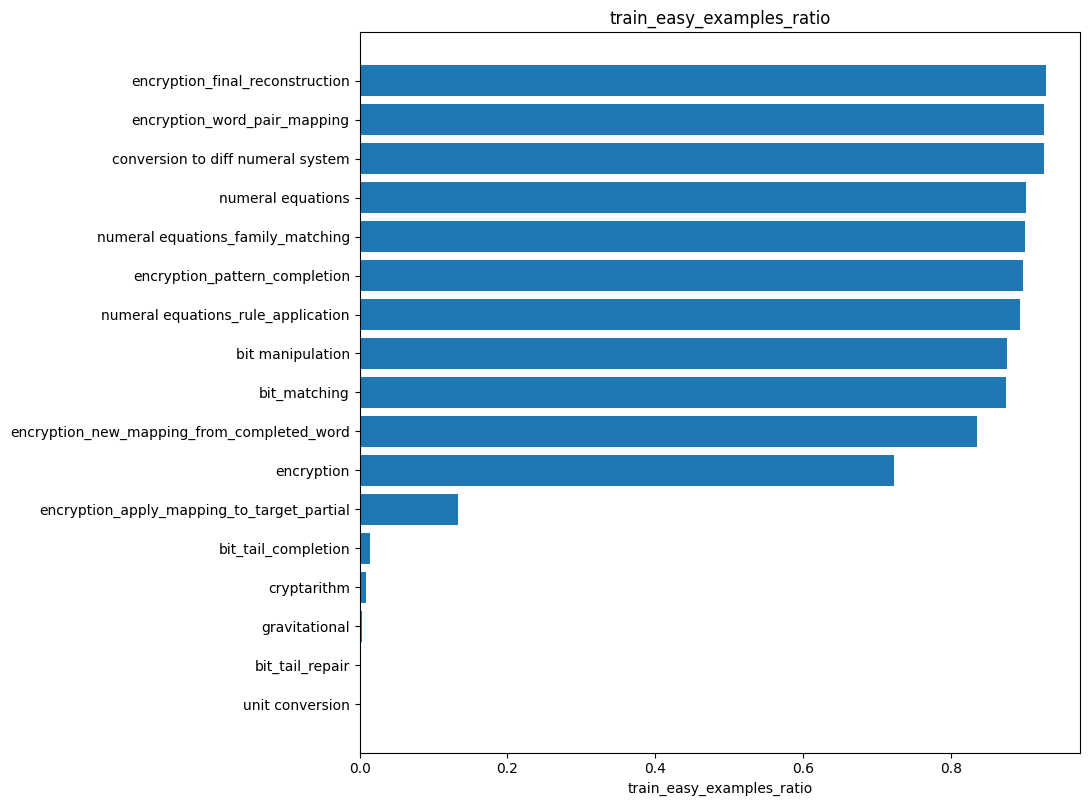

In [7]:
def plot_metric(df, metric, title=None, top_n=None):
    if df.empty or metric not in df.columns:
        print("Missing metric:", metric)
        return

    plot_df = df[["label", metric]].dropna().copy()
    plot_df = plot_df.sort_values(metric, ascending=True)

    if top_n is not None and len(plot_df) > top_n:
        plot_df = plot_df.tail(top_n)

    plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.title(title or metric)
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()

for metric in [
    "eval_difficulty_score",
    "eval_boxed_answer_mean_nll",
    "eval_hard_examples_ratio",
    "train_difficulty_score",
    "train_boxed_answer_mean_nll",
    "train_format_mean_nll",
    "train_easy_examples_ratio",
]:
    if metric in label_cmp.columns:
        plot_metric(label_cmp, metric)


### Что считать высоким на графиках

- `difficulty_score > 0.10` — уже заметно hard.
- `difficulty_score > 0.20` — очень hard.
- `boxed_answer_mean_nll > 0.08` — ответ реально плохо учится.
- `hard_examples_ratio > 0.25` — много проблемных примеров.
- `easy_examples_ratio > 0.70` — можно заметно downsample.


## 7. Section diagnostics: CoT / Final / Boxed / Format

In [8]:
section_cols = [
    "train_cot_mean_nll",
    "train_final_answer_mean_nll",
    "train_boxed_answer_mean_nll",
    "train_format_mean_nll",
    "eval_cot_mean_nll",
    "eval_final_answer_mean_nll",
    "eval_boxed_answer_mean_nll",
    "eval_format_mean_nll",
]

available_section_cols = [c for c in section_cols if c in label_cmp.columns]

section_view_cols = ["label", "decision_score"] + available_section_cols
section_view = label_cmp[section_view_cols].copy() if not label_cmp.empty else pd.DataFrame()
display(section_view)


,label,decision_score,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll
16,unit conversion,2.901042,NaN,0.029282,0.001139,0.211156,NaN,0.002227,0.001061,0.147831
5,cryptarithm,1.410204,NaN,0.089066,0.222991,0.221172,NaN,0.011304,0.087483,0.061461
3,bit_tail_repair,0.624004,NaN,0.040310,NaN,0.270711,NaN,NaN,NaN,NaN
2,bit_tail_completion,0.445048,NaN,0.029310,NaN,0.197494,NaN,NaN,NaN,NaN
7,encryption_apply_mapping_to_target_partial,0.245224,NaN,0.032996,0.002202,0.179303,NaN,NaN,NaN,NaN
15,numeral equations_rule_application,0.152186,NaN,0.033384,0.004816,0.077030,NaN,NaN,NaN,NaN
13,numeral equations,0.150610,NaN,0.031733,0.000894,0.062508,NaN,0.000439,0.001217,0.002546
9,encryption_new_mapping_from_completed_word,0.129113,NaN,0.034516,0.010283,0.079928,NaN,NaN,NaN,NaN
12,gravitational,0.126150,NaN,0.032151,0.001415,0.054270,NaN,0.001997,0.001879,0.031216
4,conversion to diff numeral system,0.119623,NaN,0.041419,0.002481,0.054891,NaN,0.001169,0.002272,0.001544


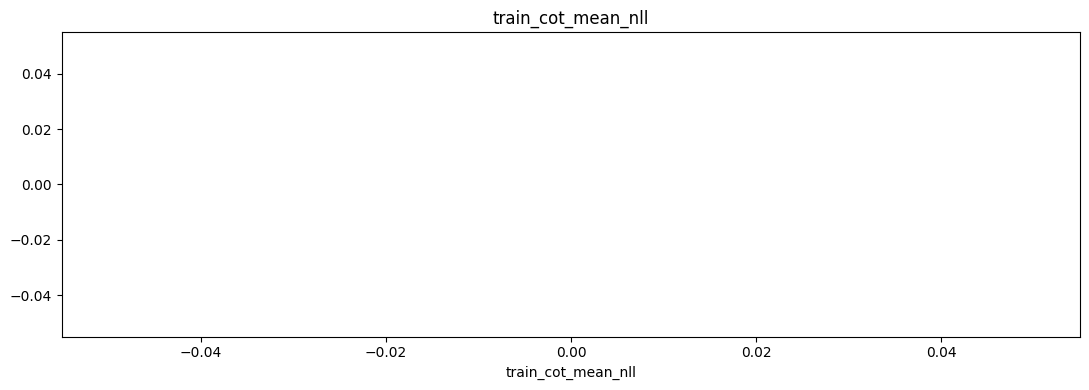

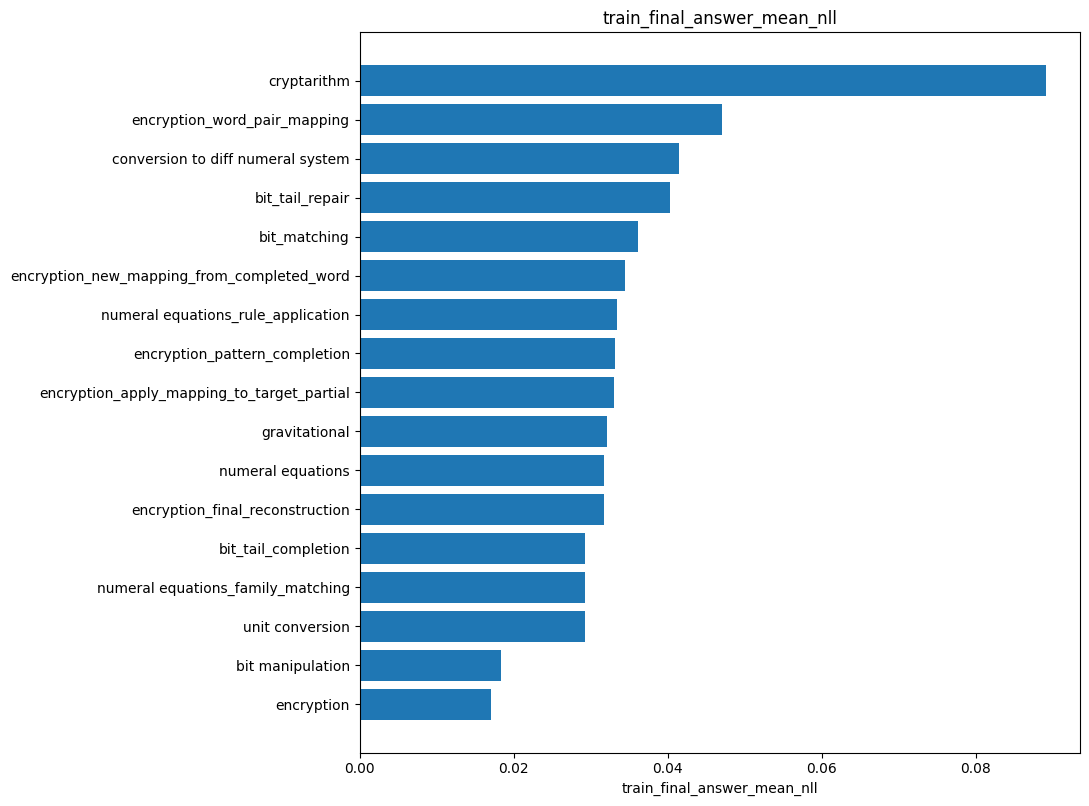

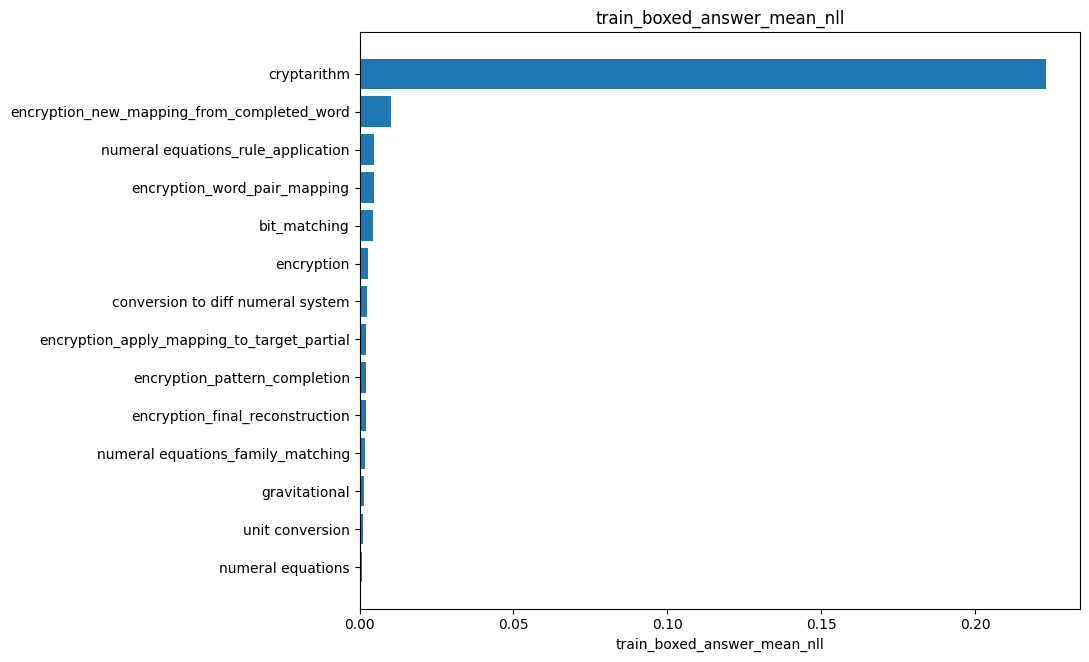

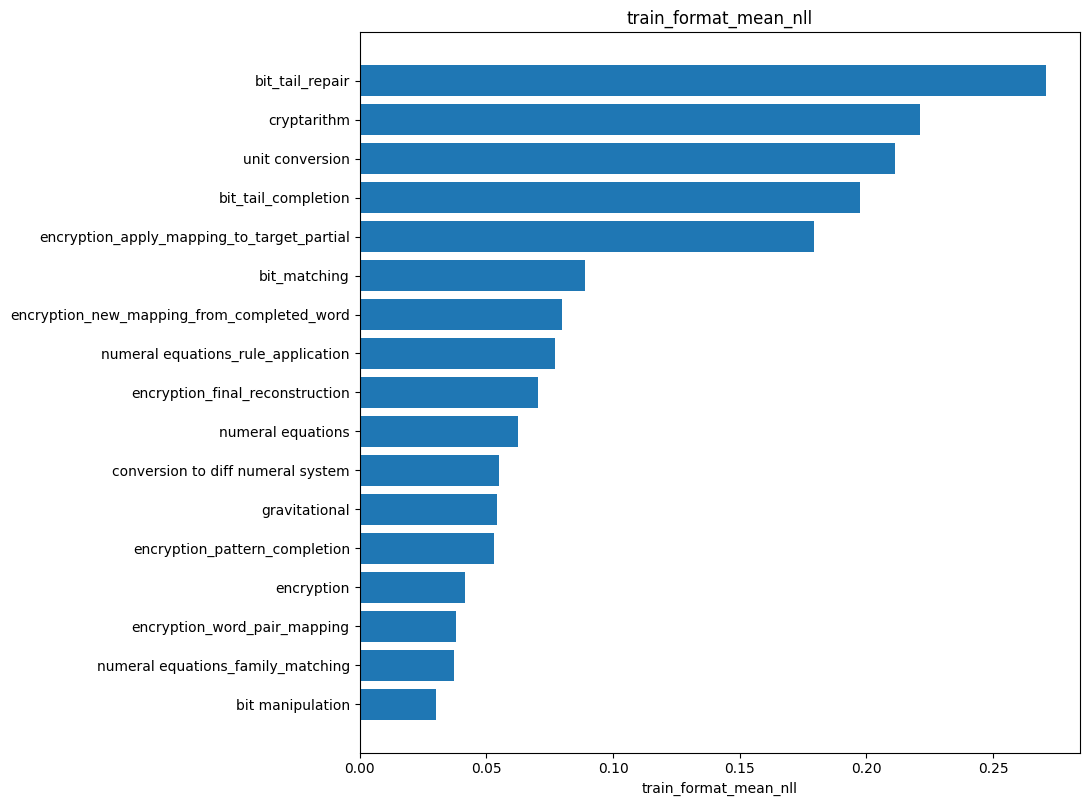

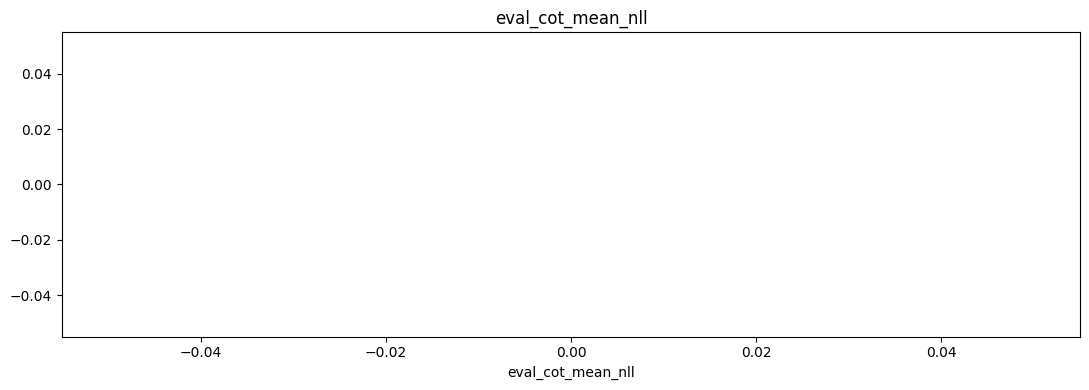

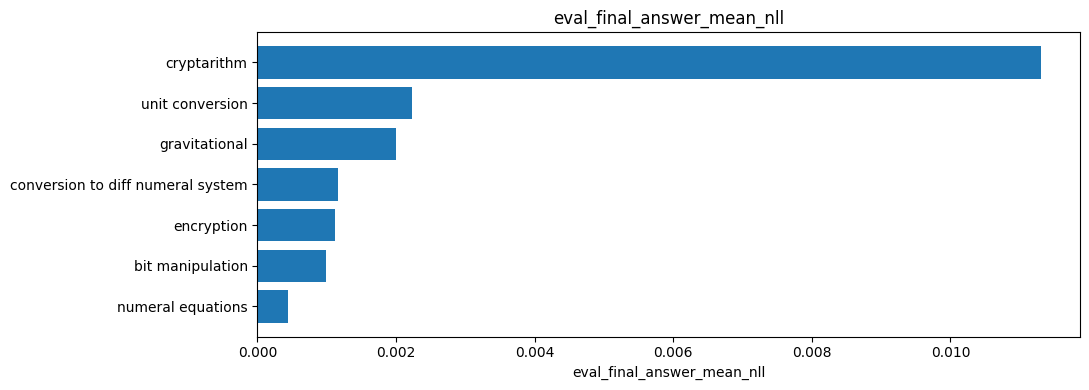

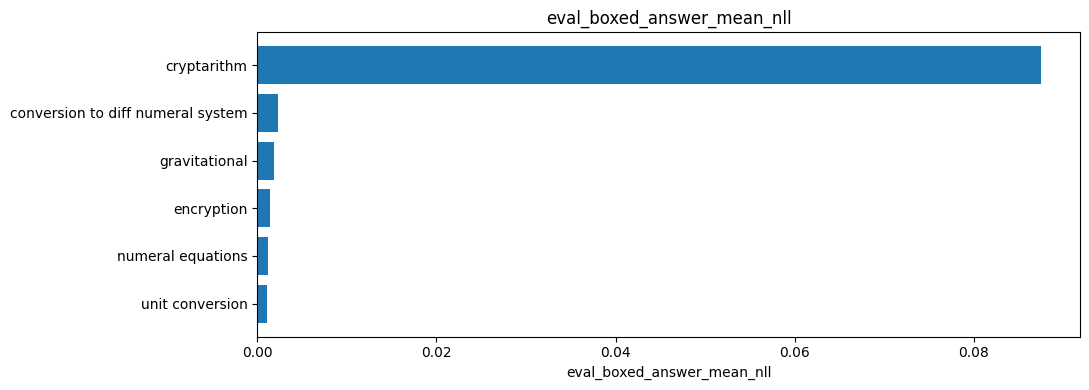

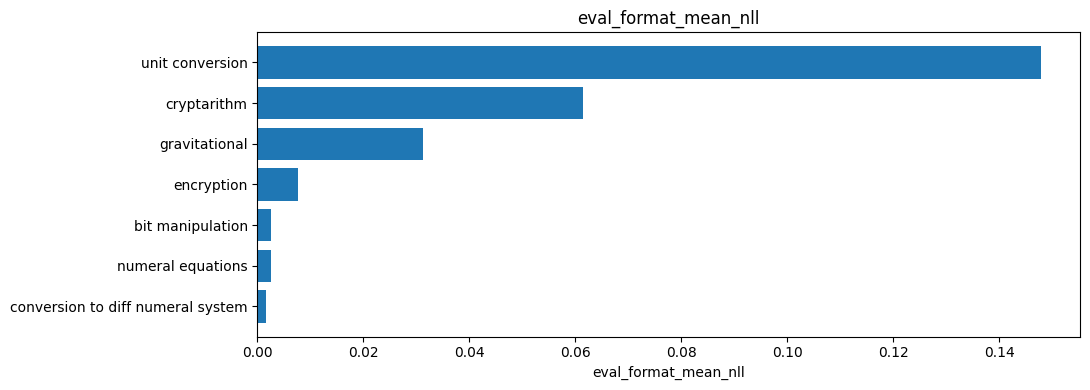

In [9]:
def plot_section_metric(prefix):
    cols = [
        f"{prefix}_cot_mean_nll",
        f"{prefix}_final_answer_mean_nll",
        f"{prefix}_boxed_answer_mean_nll",
        f"{prefix}_format_mean_nll",
    ]
    cols = [c for c in cols if c in label_cmp.columns]

    if label_cmp.empty or not cols:
        print("No section cols for", prefix)
        return

    for col in cols:
        plot_df = label_cmp[["label", col]].dropna().sort_values(col, ascending=True)
        plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
        plt.barh(plot_df["label"], plot_df[col])
        plt.title(col)
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

plot_section_metric("train")
plot_section_metric("eval")


### Как читать section diagnostics

- `boxed_answer_mean_nll` высокий → модель плохо предсказывает сам ответ. Это лучший сигнал для усиления.
- `format_mean_nll` высокий → модель страдает от шаблона/служебных токенов. Не дублировать вслепую.
- `cot_mean_nll` высокий, но `boxed_answer_mean_nll` низкий → модель плохо повторяет reasoning trace, но answer может быть нормальный.
- `final_answer_mean_nll` высокий → проблема вокруг `Final Answer: \boxed{...}`, но не обязательно в самом числе/ответе.


## 8. Source + label

In [10]:
def prepare_by_source_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "source", "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p95_mean_nll", "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c not in ["source", "label"]})
    return out

train_sl = prepare_by_source_label(train["by_source_label"], "train")
eval_sl = prepare_by_source_label(eval_["by_source_label"], "eval")

if not train_sl.empty and not eval_sl.empty:
    sl_cmp = train_sl.merge(eval_sl, on=["source", "label"], how="outer")
elif not train_sl.empty:
    sl_cmp = train_sl.copy()
else:
    sl_cmp = eval_sl.copy()

if not sl_cmp.empty:
    sl_cmp["decision_score"] = (
        sl_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + sl_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + sl_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + sl_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )
    sl_cmp = sl_cmp.sort_values("decision_score", ascending=False)

display(sl_cmp)


,source,label,train_count,train_unique_ids,train_difficulty_score,train_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,decision_score
18,solver,unit conversion,1435,1435,0.562431,0.200074,0.390734,0.071689,0.848034,NaN,0.001139,0.211156,0.001139,0.0,0.287075,1.000000,0.696167,0.000000,318.0,159.0,0.418245,0.139259,0.191263,0.054260,0.879456,NaN,0.001061,0.147831,0.001061,0.0,0.205480,1.0000,0.54717,0.000000,2.901042
7,solver,cryptarithm,50,50,0.405878,0.202321,1.121044,0.047365,0.861669,NaN,0.224819,0.211897,0.269819,0.0,0.261726,0.540000,0.300000,0.060000,16.0,8.0,0.084528,0.057883,0.111467,0.015072,0.930642,NaN,0.087483,0.061461,0.129150,0.0,0.076843,0.4375,0.12500,0.000000,1.406150
5,solver,bit_tail_repair,137,137,0.624004,0.261020,1.041045,0.085126,0.821633,NaN,NaN,0.270711,0.000000,0.0,0.359368,0.948905,0.671533,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.624004
4,solver,bit_tail_completion,74,74,0.445048,0.191281,0.969022,0.059888,0.855879,NaN,NaN,0.197494,0.000000,0.0,0.259462,0.824324,0.378378,0.013514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.445048
0,generated,cryptarithm,500,500,0.410337,0.212534,1.025093,0.050031,0.860190,NaN,0.222802,0.222099,0.275560,0.0,0.274500,0.662000,0.368000,0.004000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.410337
9,solver,encryption_apply_mapping_to_target_partial,987,987,0.245224,0.149330,0.634423,0.034423,0.926228,NaN,0.002202,0.179303,0.002202,0.0,0.221013,0.434650,0.146910,0.133739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.245224
17,solver,numeral equations_rule_application,1338,1335,0.152186,0.071707,0.570820,0.014152,0.966083,NaN,0.004816,0.077030,0.004809,0.0,0.092510,0.074738,0.062780,0.893871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.152186
15,solver,numeral equations,510,510,0.138090,0.062171,0.480102,0.014267,0.971789,NaN,0.000894,0.062508,0.000890,0.0,0.076859,0.078431,0.068627,0.901961,106.0,53.0,0.005043,0.002534,0.007126,0.000276,0.998901,NaN,0.001217,0.002546,0.001217,0.0,0.002825,0.0000,0.00000,1.000000,0.150610
11,solver,encryption_new_mapping_from_completed_word,1274,1274,0.129113,0.068055,0.148689,0.014527,0.965632,NaN,0.010283,0.079928,0.013808,0.0,0.097331,0.069859,0.050235,0.835165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129113
14,solver,gravitational,1437,1437,0.077622,0.053460,0.087939,0.017682,0.965753,NaN,0.001415,0.054270,0.001415,0.0,0.072323,0.054976,0.045929,0.002784,320.0,160.0,0.022385,0.030498,0.036992,0.011624,0.978684,NaN,0.001879,0.031216,0.001879,0.0,0.043133,0.0000,0.00000,0.000000,0.126150


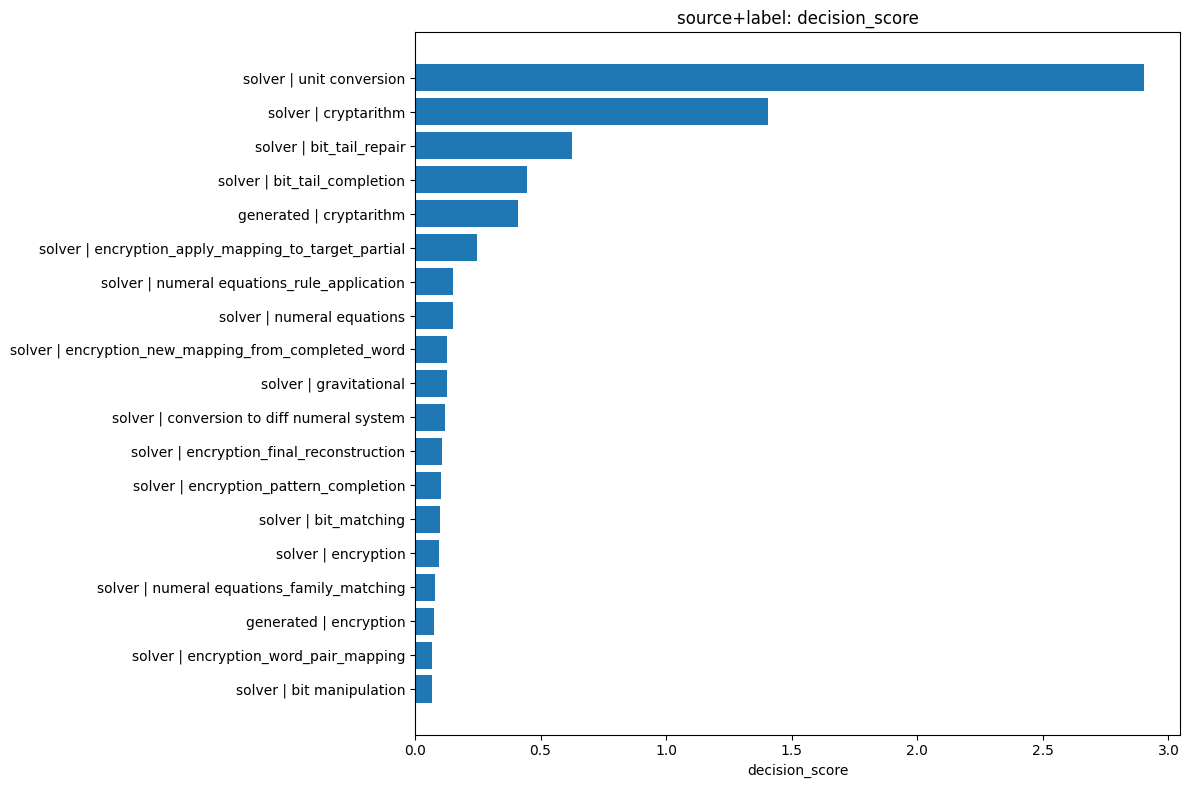

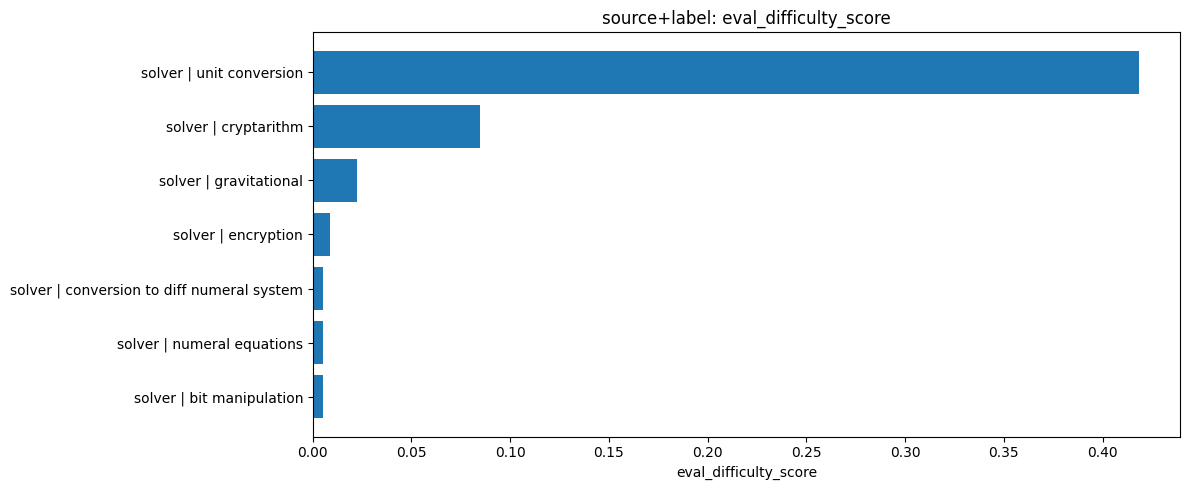

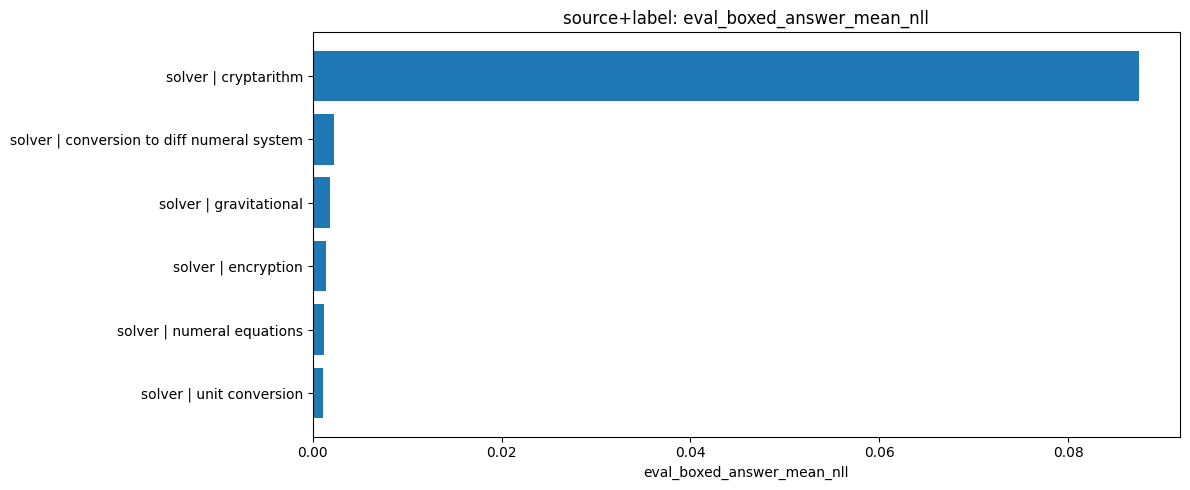

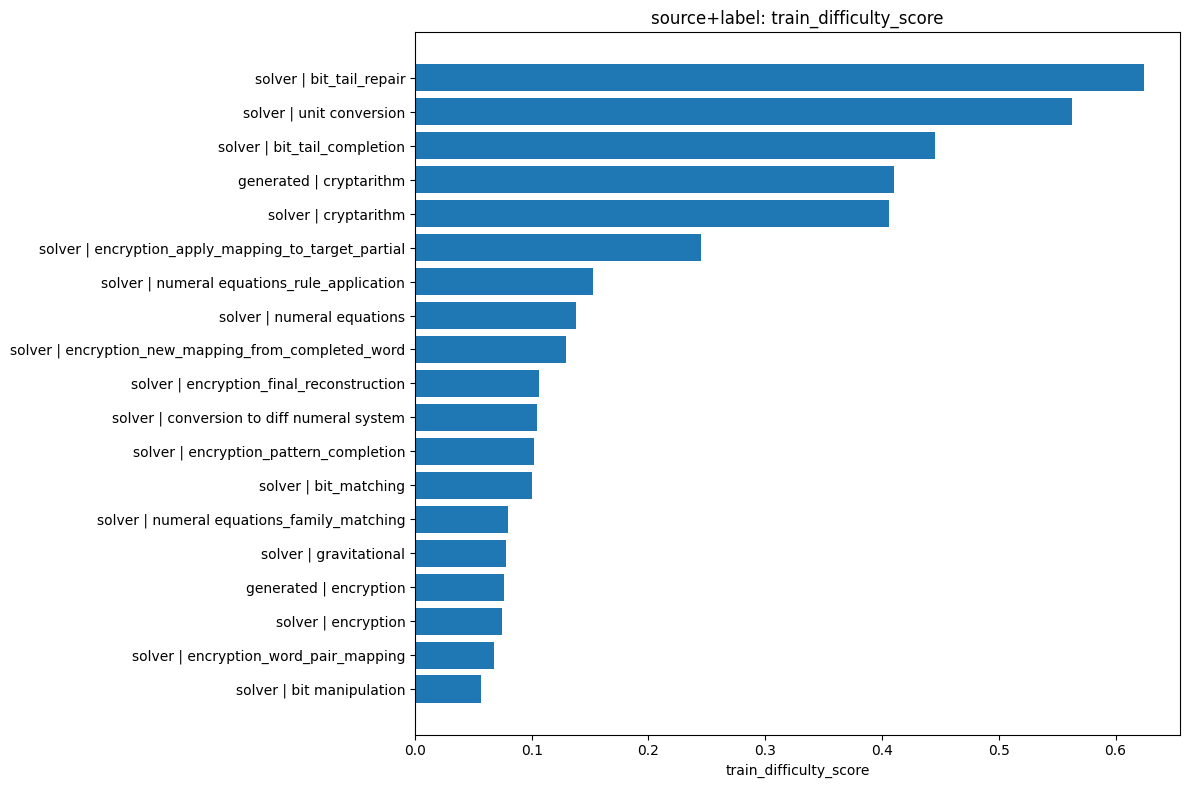

In [11]:
if not sl_cmp.empty:
    top_sl = sl_cmp.head(20).copy()
    top_sl["source_label"] = top_sl["source"].astype(str) + " | " + top_sl["label"].astype(str)

    for metric in ["decision_score", "eval_difficulty_score", "eval_boxed_answer_mean_nll", "train_difficulty_score"]:
        if metric not in top_sl.columns:
            continue
        plot_df = top_sl[["source_label", metric]].dropna().sort_values(metric, ascending=True)
        plt.figure(figsize=(12, max(5, len(plot_df) * 0.42)))
        plt.barh(plot_df["source_label"], plot_df[metric])
        plt.title("source+label: " + metric)
        plt.xlabel(metric)
        plt.tight_layout()
        plt.show()


## 9. Bad tokens

In [12]:
bad_train = train["bad_tokens"].copy()
bad_eval = eval_["bad_tokens"].copy()

if bad_train.empty:
    print("train bad_tokens is empty. Скорее всего, SFT запускался старой telemetry без top_bad_tokens.")
else:
    print("Top train bad tokens")
    display(bad_train.head(80))

if bad_eval.empty:
    print("eval bad_tokens is empty.")
else:
    print("Top eval bad tokens")
    display(bad_eval.head(80))


Top train bad tokens


,source,label,section,token_text,count,mean_logprob,min_logprob,mean_nll,sample_context_1,sample_context_2,sample_context_3
0,solver,bit_matching,format,,6222,-0.172275,-7.910830,0.172275,0x\n26 37 40 51 62,\n1 45 54 47 74\n2,\n1 70 07 02 20 03
1,solver,bit_matching,boxed_answer,,2044,-0.022334,-0.045017,0.022334,\n4 absent\n5 absent\n6 60 06\n7,20 24 42 47 74\n6 absent,41\n6 absent\n7 61\n\nLeft\nnone\nBest
2,solver,conversion to diff numeral system,format,,1907,-0.143807,-11.525135,0.143807,land.\n\nLooking at the examples provided:\n 1 -> I\n 8,land.\n\nLooking at the examples provided:\n 10 -> X\n,land.\n\nLooking at the examples provided:\n 11 -> XI\n
3,solver,bit_matching,format,\n,1675,-0.105724,-7.319344,0.105724,0 1\n1 0 2\n2,x\n62 73x\nBest: 12: 1,x\n07 10x\nBest: 34: 1
4,solver,numeral equations_rule_application,format,,1604,-0.039132,-4.663542,0.039132,83\noperation max_mod_min: 83 % 78 =,1\ndisplay format neg_prefix: normalized 71 -> visible 71\n,_prefix: normalized 71 -> visible 71\nAnswer: 71
...,...,...,...,...,...,...,...,...,...,...,...
75,solver,bit_matching,format,Best,250,-6.226674,-17.018204,6.226674,\n75 06x\nBest: 56: 1\n\n,\n73 04y\nBest: 37: 1\n\n,41\n\nLeft\nnone\nBest: none\n\nRight\n34
76,solver,conversion to diff numeral system,format,-,244,-0.023160,-0.303576,0.023160,into Roman numerals using greedy decomposition:\n - Subtract 10 (X):,into Roman numerals using greedy decomposition:\n - Subtract 10 (X):,into Roman numerals using greedy decomposition:\n - Subtract 10 (X):
77,solver,encryption_new_mapping_from_completed_word,format,in,243,-0.016456,-0.028191,0.016456,"overs', looking only at the ? positions in 'disco?ers'. The newly","ful', looking only at the ? positions in 'color?ul'. The newly deduced","dark', looking only at the ? positions in 'dar?'. The newly deduced mappings"
78,solver,numeral equations_family_matching,format,3,229,-0.298599,-5.180744,0.298599,"r2:A=77,B=3,Y=801 | row1","3,B=17,Y=731 | row1:Y=2",Family block 03: abs_diff/neg_abs_diff


Top eval bad tokens


,source,label,section,token_text,count,mean_logprob,min_logprob,mean_nll,sample_context_1,sample_context_2,sample_context_3
0,solver,conversion to diff numeral system,format,,430,-0.022061,-0.044121,0.022061,10 (X): remainder is 2.\n - Subtract 1,50 (L): remainder is 22.\n - Subtract,(X): remainder is 2.\n - Subtract 1 (I):
1,solver,bit manipulation,format,,339,-0.268965,-6.344543,0.268965,5y\n15 04 73 62 51,7 0\n\nOutput 6: 01100111,\n\nLeft\n67 70 01y\n76 0
2,solver,encryption,format,'.\n\n,234,-0.795472,-6.605846,0.795472,-> 'dragon found under wonderland'.\n\nAnalyzing Example 5: 'ng,"ars' -> 'rabbit found through garden'.\n\nCombining these extracted rules, we establish",Extracted: 'i'='v'.\n\nAnalyzing Example 3: 'ap
3,solver,unit conversion,format,6,225,-2.610441,-8.893656,2.610441,", 70.919664]\nBoth bounds round to exactly","2 boundaries: [52.669788, 52","boundaries: [43.706262, 43."
4,solver,unit conversion,format,4,206,-2.644803,-6.643959,2.644803,"9, 10.794334]\nBoth bounds round to",10.794334]\nBoth bounds round to exactly 1,"23, 0.54401408]\n\nTarget"
...,...,...,...,...,...,...,...,...,...,...,...
75,solver,encryption,format,a,16,-0.939266,-7.041859,0.939266,"', 'z'='a', 'a'='n', 'd'='","'. Extracted: 'r'='a', 'x'='c'.\nWord",we get a partial decryption: 'a?ice fo??ows near cast?
76,solver,encryption,format,z,16,-0.805844,-3.844215,0.805844,'the golden king draws'.\nWord 'zqnxld' (6 letters),'the silver princess studies'.\nWord 'zcmpfb' (6 letters) maps,'l'='p'.\nWord 'zxevt' (5 letters) maps
77,solver,encryption,format,v,16,-0.688164,-3.252998,0.688164,"'colorful'. Extracted: 'v'='r', 'g'='","to 'school'. Extracted: 'v'='h', 'h'='",'w'='h'.\nWord 'vjmdgjr' (7 letters
78,solver,encryption,format,draws,16,-0.327932,-1.347584,0.327932,a partial decryption: '?ouse draws the curious story'.\n\nSince some letters are,partial decryption: 'the clever dragon draws'.\nThe final fully decrypted text is,a partial decryption: '??een draws in mo?ntain'.\n\nSince some


In [13]:
def section_summary(bad_df):
    if bad_df.empty or "section" not in bad_df.columns:
        return pd.DataFrame()

    out = bad_df.groupby("section", dropna=False).agg(
        rows=("token_text", "count"),
        total_count=("count", "sum"),
        mean_token_nll=("mean_nll", "mean"),
        worst_logprob=("min_logprob", "min"),
    ).reset_index().sort_values("total_count", ascending=False)

    total = out["total_count"].sum()
    if total > 0:
        out["count_share"] = out["total_count"] / total

    return out

train_section_summary = section_summary(bad_train)
eval_section_summary = section_summary(bad_eval)

print("TRAIN bad token sections")
display(train_section_summary)

print("EVAL bad token sections")
display(eval_section_summary)


TRAIN bad token sections


,section,rows,total_count,mean_token_nll,worst_logprob,count_share
2,format,4347,93667,2.001057,-28.685316,0.907890
0,boxed_answer,319,6636,0.395330,-13.389185,0.064321
1,final_answer,117,2867,1.488256,-15.758310,0.027789


EVAL bad token sections


,section,rows,total_count,mean_token_nll,worst_logprob,count_share
2,format,640,8288,0.951177,-13.568565,0.992575
1,final_answer,9,54,0.091310,-1.049831,0.006467
0,boxed_answer,8,8,0.395193,-1.700768,0.000958


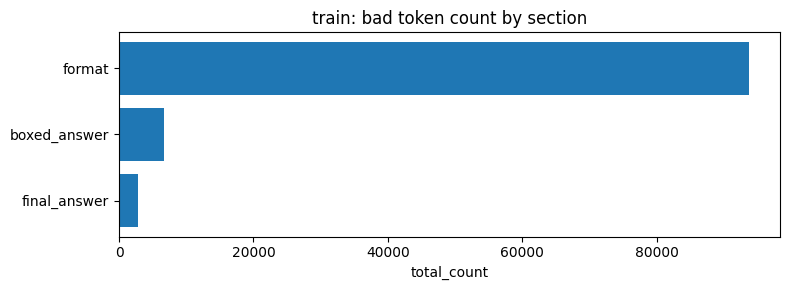

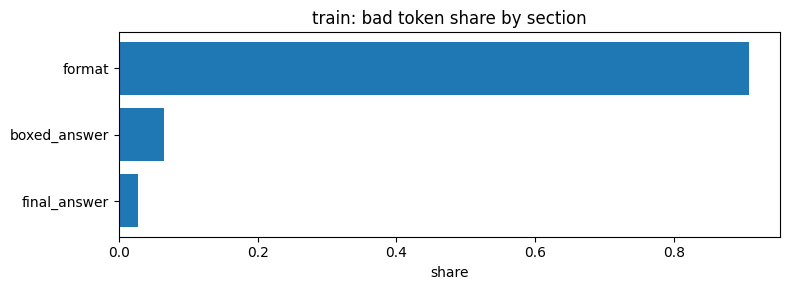

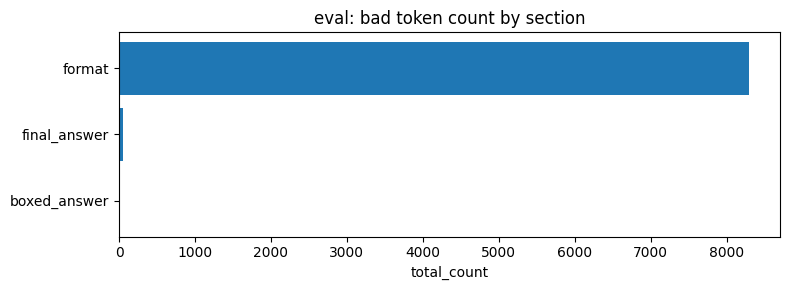

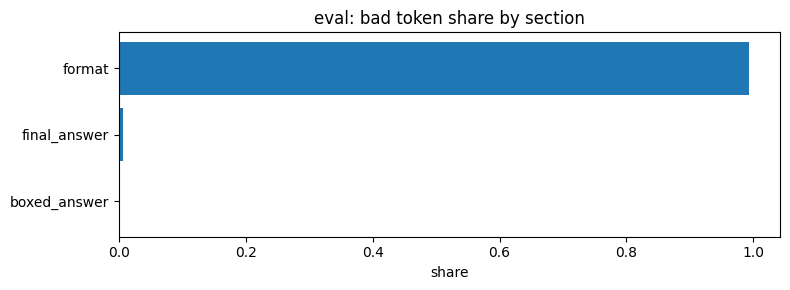

In [14]:
for name, df in [("train", train_section_summary), ("eval", eval_section_summary)]:
    if df.empty:
        continue

    plot_df = df.sort_values("total_count", ascending=True)

    plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
    plt.barh(plot_df["section"], plot_df["total_count"])
    plt.title(f"{name}: bad token count by section")
    plt.xlabel("total_count")
    plt.tight_layout()
    plt.show()

    if "count_share" in plot_df.columns:
        plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
        plt.barh(plot_df["section"], plot_df["count_share"])
        plt.title(f"{name}: bad token share by section")
        plt.xlabel("share")
        plt.tight_layout()
        plt.show()


### Ключ к bad tokens

Если много плохих токенов в `format`, это может быть ложная hardness: модель страдает от формата, а не от задачи.

Если плохие токены в `boxed_answer`, это уже ближе к реальной ошибке решения.

Если плохие токены в `cot`, смотри context:
- decimal boundaries / ambiguity / infinite precision → возможно слишком шумный CoT;
- operation/reasoning/derived value → может быть настоящая reasoning-hardness.


## 10. Bad tokens by label and section

In [15]:
def bad_tokens_by_label_section(bad_df, name):
    if bad_df.empty:
        print(name, "bad tokens empty")
        return pd.DataFrame()

    out = bad_df.groupby(["label", "section"], dropna=False).agg(
        rows=("token_text", "count"),
        total_count=("count", "sum"),
        mean_token_nll=("mean_nll", "mean"),
        worst_logprob=("min_logprob", "min"),
    ).reset_index()

    out = out.sort_values(["total_count", "mean_token_nll"], ascending=[False, False])
    print(name)
    display(out.head(80))
    return out

train_bad_label_section = bad_tokens_by_label_section(bad_train, "TRAIN bad tokens by label/section")
eval_bad_label_section = bad_tokens_by_label_section(bad_eval, "EVAL bad tokens by label/section")


TRAIN bad tokens by label/section


,label,section,rows,total_count,mean_token_nll,worst_logprob
3,bit_matching,format,23,13364,1.833539,-27.195316
14,encryption,format,1698,10486,2.439634,-28.685316
37,numeral equations_family_matching,format,137,8468,1.192975,-23.770451
42,unit conversion,format,23,7165,5.937765,-17.467770
31,gravitational,format,24,7156,5.467498,-26.019323
9,conversion to diff numeral system,format,100,6753,0.509087,-15.410194
0,bit manipulation,format,78,6320,4.123032,-20.829014
40,numeral equations_rule_application,format,92,6251,1.407198,-27.478245
23,encryption_new_mapping_from_completed_word,format,288,5419,0.299087,-23.756367
29,encryption_word_pair_mapping,format,238,5123,0.308385,-20.635895


EVAL bad tokens by label/section


,label,section,rows,total_count,mean_token_nll,worst_logprob
9,gravitational,format,10,1600,2.316298,-5.345125
11,unit conversion,format,11,1590,2.656026,-8.893656
8,encryption,format,357,1569,0.972300,-10.915617
3,conversion to diff numeral system,format,74,1525,0.017983,-0.794163
0,bit manipulation,format,51,1400,1.947791,-13.568565
10,numeral equations,format,101,530,0.665725,-11.095920
6,cryptarithm,format,36,74,1.148786,-5.684956
2,conversion to diff numeral system,final_answer,7,51,0.017820,-0.029148
4,cryptarithm,boxed_answer,4,4,0.774301,-1.700768
1,conversion to diff numeral system,boxed_answer,4,4,0.016086,-0.023224


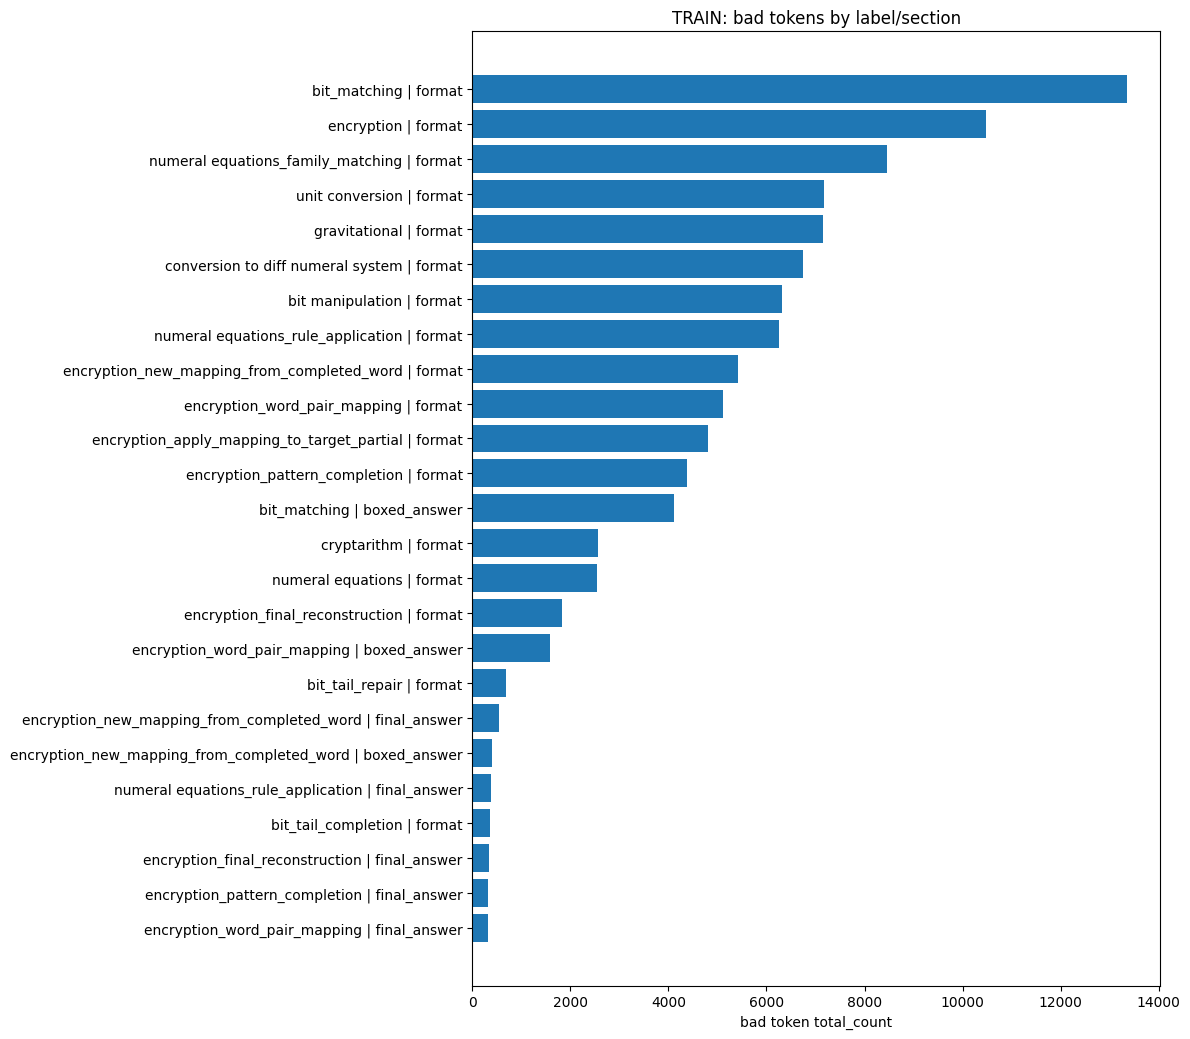

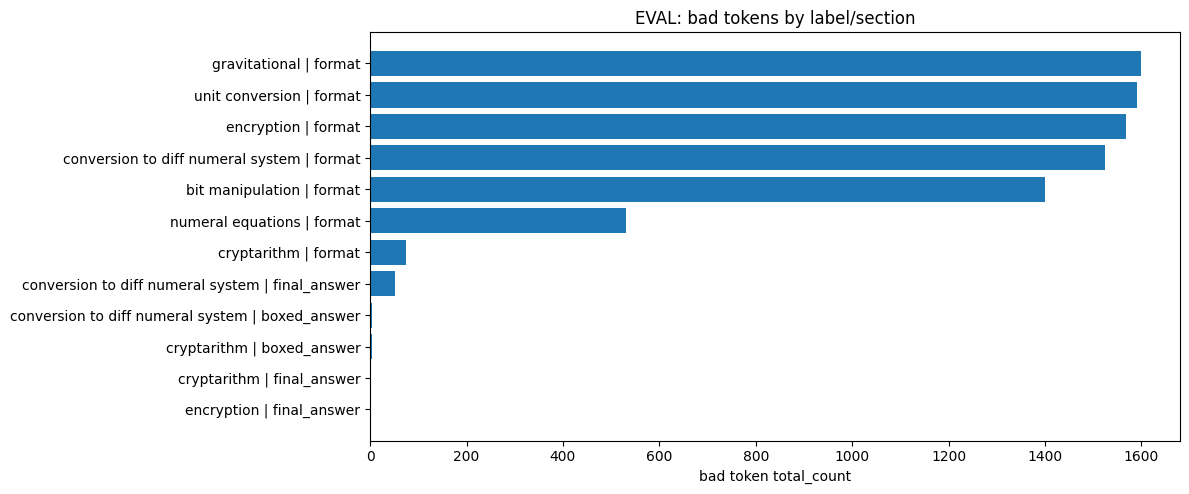

In [16]:
def plot_bad_label_section(df, title):
    if df.empty:
        return

    top = df.head(25).copy()
    top["label_section"] = top["label"].astype(str) + " | " + top["section"].astype(str)
    top = top.sort_values("total_count", ascending=True)

    plt.figure(figsize=(12, max(5, len(top) * 0.42)))
    plt.barh(top["label_section"], top["total_count"])
    plt.title(title)
    plt.xlabel("bad token total_count")
    plt.tight_layout()
    plt.show()

plot_bad_label_section(train_bad_label_section, "TRAIN: bad tokens by label/section")
plot_bad_label_section(eval_bad_label_section, "EVAL: bad tokens by label/section")


## 11. Checkpoint dynamics from raw telemetry

In [17]:
def read_jsonl_files(root: Path) -> pd.DataFrame:
    files = sorted(root.rglob("*.jsonl"))
    rows = []

    for path in files:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    for col in [
        "checkpoint_bucket", "step", "mean_nll", "p05_logprob", "hard_token_ratio",
        "near_zero_token_ratio", "boxed_answer_mean_nll", "cot_mean_nll", "format_mean_nll"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

train_raw = read_jsonl_files(TRAIN_TELEMETRY_DIR) if TRAIN_TELEMETRY_DIR.exists() else pd.DataFrame()
eval_raw = read_jsonl_files(EVAL_TELEMETRY_DIR) if EVAL_TELEMETRY_DIR.exists() else pd.DataFrame()

print("train_raw:", train_raw.shape)
print("eval_raw:", eval_raw.shape)


train_raw: (20510, 40)
eval_raw: (1670, 40)


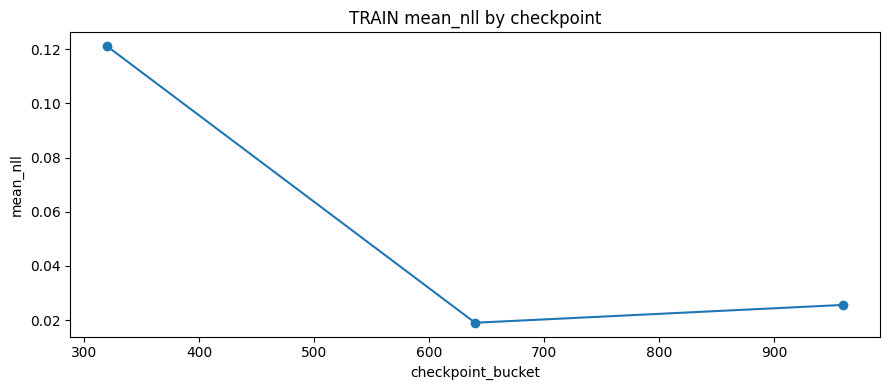

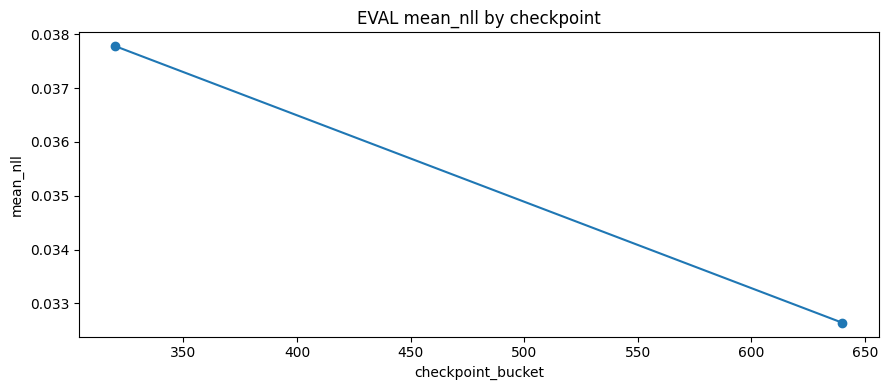

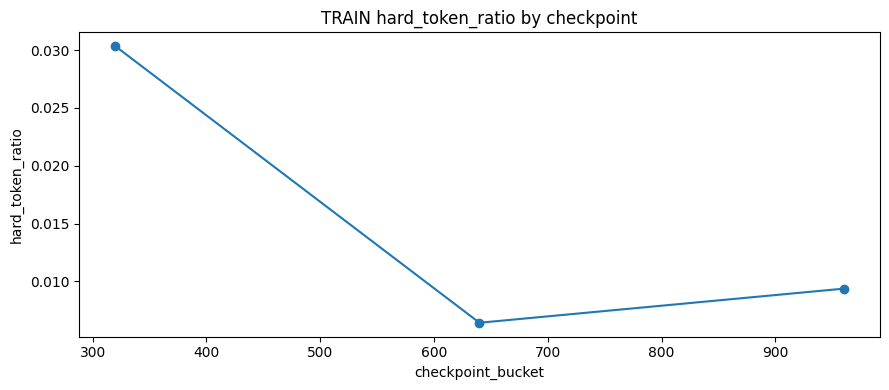

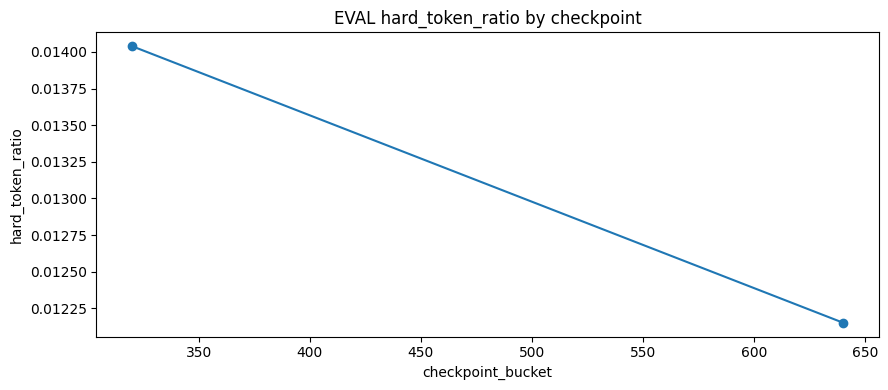

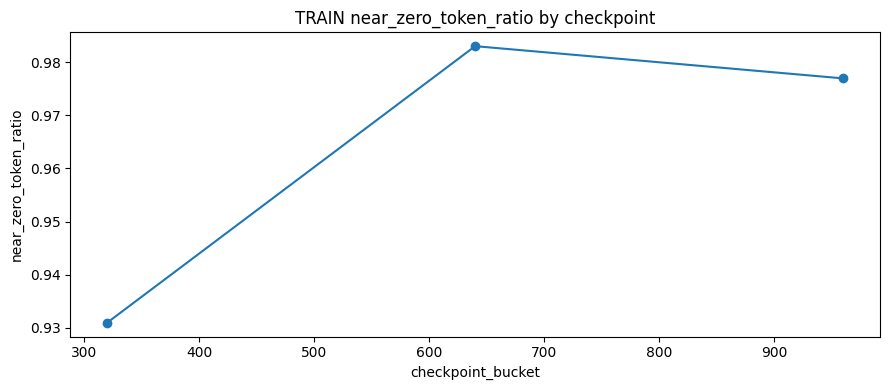

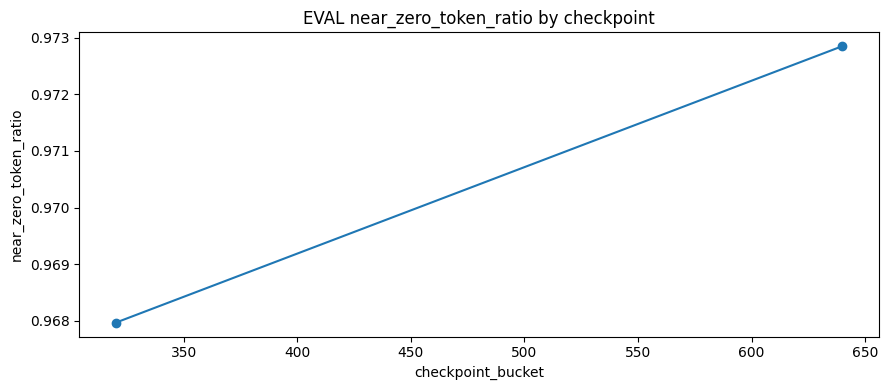

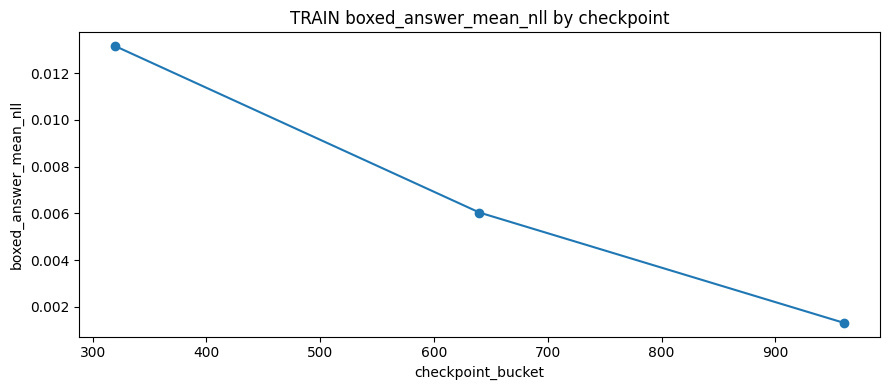

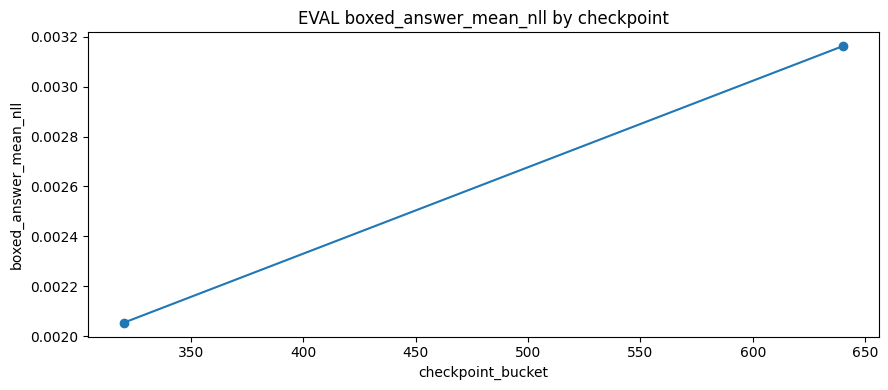

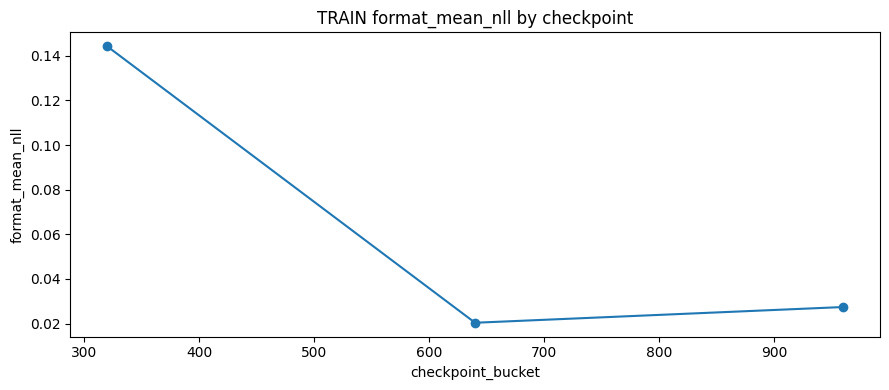

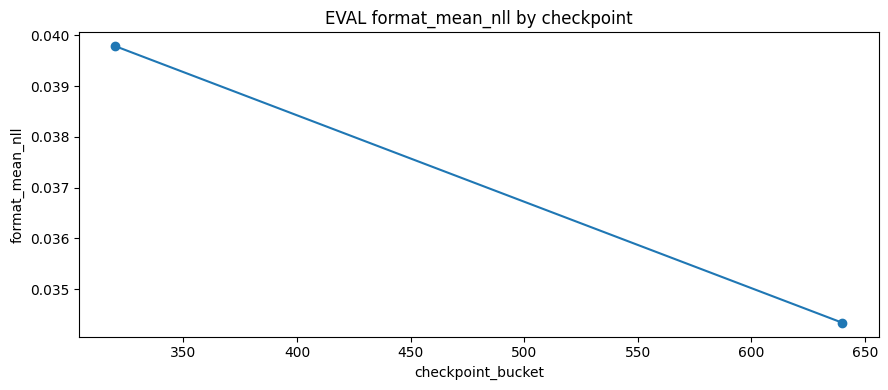

In [18]:
def plot_checkpoint_metric(raw_df, metric, title):
    if raw_df.empty or metric not in raw_df.columns or "checkpoint_bucket" not in raw_df.columns:
        print("No data for", title)
        return

    by_ckpt = raw_df.groupby("checkpoint_bucket", dropna=False)[metric].mean().reset_index()
    by_ckpt = by_ckpt.sort_values("checkpoint_bucket")

    plt.figure(figsize=(9, 4))
    plt.plot(by_ckpt["checkpoint_bucket"], by_ckpt[metric], marker="o")
    plt.title(title)
    plt.xlabel("checkpoint_bucket")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

for metric in ["mean_nll", "hard_token_ratio", "near_zero_token_ratio", "boxed_answer_mean_nll", "format_mean_nll"]:
    plot_checkpoint_metric(train_raw, metric, "TRAIN " + metric + " by checkpoint")
    plot_checkpoint_metric(eval_raw, metric, "EVAL " + metric + " by checkpoint")


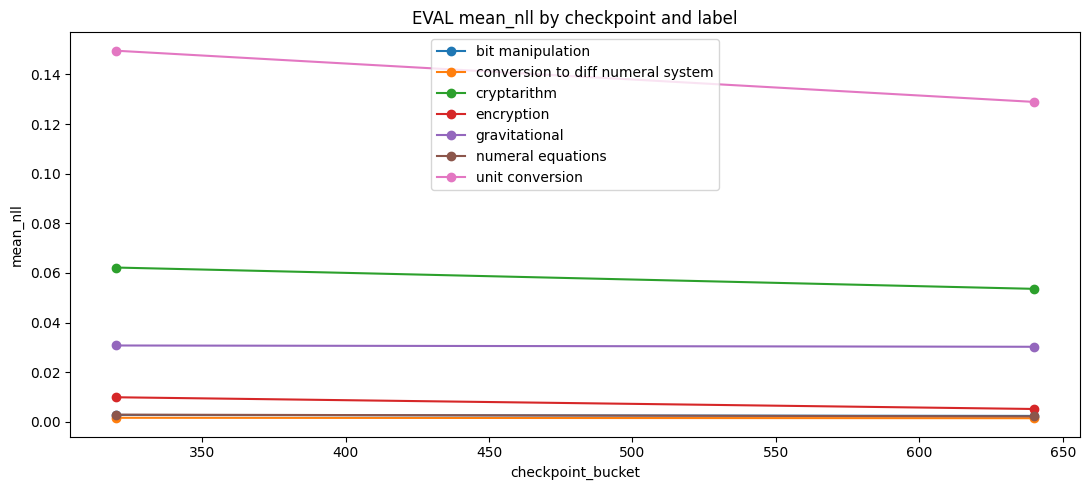

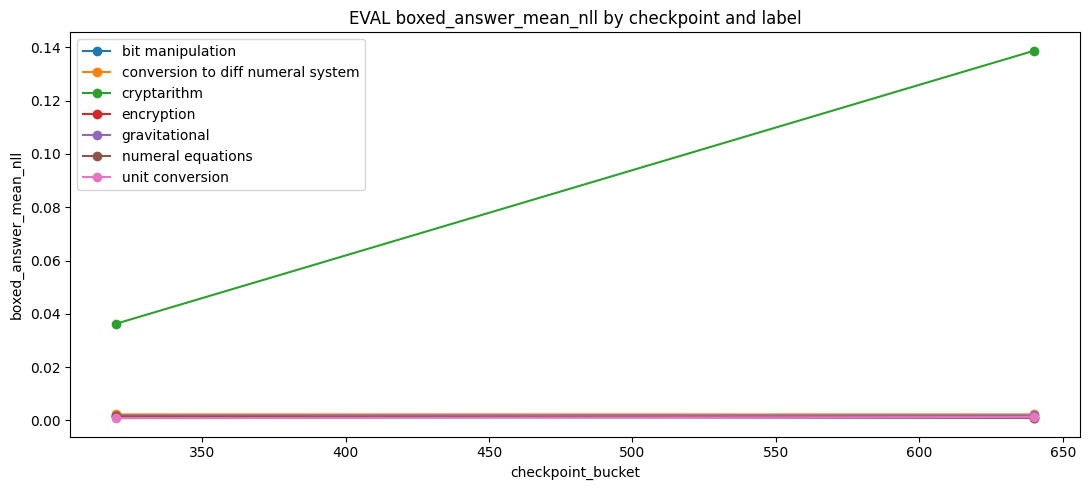

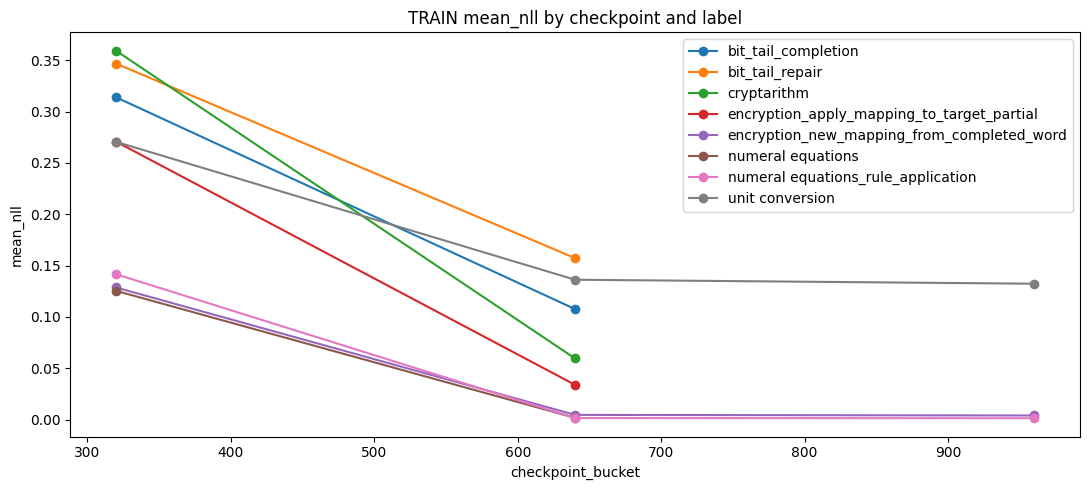

In [19]:
def plot_checkpoint_metric_by_label(raw_df, metric, top_labels=None, title=None):
    if raw_df.empty or metric not in raw_df.columns:
        print("No data for", title or metric)
        return

    if top_labels is None:
        if "label" not in raw_df.columns:
            return
        top_labels = raw_df.groupby("label")[metric].mean().sort_values(ascending=False).head(8).index.tolist()

    use_df = raw_df[raw_df["label"].isin(top_labels)].copy()
    pivot = use_df.groupby(["checkpoint_bucket", "label"])[metric].mean().reset_index()

    plt.figure(figsize=(11, 5))
    for label, group in pivot.groupby("label"):
        group = group.sort_values("checkpoint_bucket")
        plt.plot(group["checkpoint_bucket"], group[metric], marker="o", label=str(label))
    plt.title(title or metric)
    plt.xlabel("checkpoint_bucket")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_checkpoint_metric_by_label(eval_raw, "mean_nll", title="EVAL mean_nll by checkpoint and label")
plot_checkpoint_metric_by_label(eval_raw, "boxed_answer_mean_nll", title="EVAL boxed_answer_mean_nll by checkpoint and label")
plot_checkpoint_metric_by_label(train_raw, "mean_nll", title="TRAIN mean_nll by checkpoint and label")


### Как читать dynamics

- eval `mean_nll` падает по checkpoint → модель реально обобщает.
- train падает, eval стоит → запоминание train traces.
- eval `boxed_answer_mean_nll` не падает → модель не учится выдавать ответ, даже если общий loss падает.


## 12. Boxed answer sequence metrics for exact-match tasks

Для задач вроде `bit manipulation` средний loss по answer может обманывать.

Пример: если answer состоит из 8 битов и модель ошибается в 1 бите, exact match уже неверный, но `boxed_answer_mean_nll` может выглядеть умеренно.

Поэтому добавляем sequence-level метрики:

```text
boxed_answer_total_nll = boxed_answer_mean_nll * boxed_answer_num_tokens
boxed_answer_sequence_prob_est = exp(-boxed_answer_total_nll)
```

Как читать:

| Метрика | Что значит |
|---|---|
| `boxed_answer_total_nll > 0.8` | whole answer уже заметно рискованный |
| `boxed_answer_total_nll > 1.6` | whole answer очень рискованный |
| `boxed_answer_sequence_prob_est < 0.45` | вероятность целиком правильно выдать ответ низкая |
| `boxed_answer_sequence_prob_est < 0.20` | очень низкая вероятность полного ответа |

Это особенно важно для `bit manipulation`, где один неправильный бит ломает весь ответ.


In [20]:
def add_boxed_sequence_metrics(raw_df: pd.DataFrame) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    required = ["label", "boxed_answer_mean_nll", "boxed_answer_num_tokens"]
    missing = [c for c in required if c not in raw_df.columns]
    if missing:
        print("Missing boxed sequence columns:", missing)
        return pd.DataFrame()

    out = raw_df.copy()

    for col in ["boxed_answer_mean_nll", "boxed_answer_num_tokens", "checkpoint_bucket"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out["boxed_answer_total_nll"] = out["boxed_answer_mean_nll"].fillna(0) * out["boxed_answer_num_tokens"].fillna(0)
    out["boxed_answer_sequence_prob_est"] = np.exp(-out["boxed_answer_total_nll"].clip(lower=0, upper=50))

    return out

train_seq_raw = add_boxed_sequence_metrics(train_raw)
eval_seq_raw = add_boxed_sequence_metrics(eval_raw)

print("train_seq_raw:", train_seq_raw.shape)
print("eval_seq_raw:", eval_seq_raw.shape)


train_seq_raw: (20510, 42)
eval_seq_raw: (1670, 42)


In [21]:
def summarize_boxed_sequence(raw_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    out = raw_df.groupby("label", dropna=False).agg(
        boxed_answer_num_tokens_mean=("boxed_answer_num_tokens", "mean"),
        boxed_answer_total_nll_mean=("boxed_answer_total_nll", "mean"),
        boxed_answer_total_nll_p50=("boxed_answer_total_nll", "median"),
        boxed_answer_total_nll_p95=("boxed_answer_total_nll", lambda x: x.quantile(0.95)),
        boxed_answer_sequence_prob_mean=("boxed_answer_sequence_prob_est", "mean"),
        boxed_answer_sequence_prob_p50=("boxed_answer_sequence_prob_est", "median"),
        boxed_answer_mean_nll_mean=("boxed_answer_mean_nll", "mean"),
        count=("id", "count") if "id" in raw_df.columns else ("label", "count"),
    ).reset_index()

    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c != "label"})
    return out

train_boxed_seq = summarize_boxed_sequence(train_seq_raw, "train")
eval_boxed_seq = summarize_boxed_sequence(eval_seq_raw, "eval")

if not train_boxed_seq.empty and not eval_boxed_seq.empty:
    boxed_seq_cmp = train_boxed_seq.merge(eval_boxed_seq, on="label", how="outer")
elif not train_boxed_seq.empty:
    boxed_seq_cmp = train_boxed_seq.copy()
else:
    boxed_seq_cmp = eval_boxed_seq.copy()

if not boxed_seq_cmp.empty:
    sort_col = "eval_boxed_answer_total_nll_mean" if "eval_boxed_answer_total_nll_mean" in boxed_seq_cmp.columns else "train_boxed_answer_total_nll_mean"
    boxed_seq_cmp = boxed_seq_cmp.sort_values(sort_col, ascending=False)

    # add to main decision table, so suggested weights can use it
    extra_cols = [c for c in boxed_seq_cmp.columns if c != "label"]
    label_cmp = label_cmp.merge(boxed_seq_cmp[["label"] + extra_cols], on="label", how="left")

print("Boxed sequence metrics by label")
display(boxed_seq_cmp)


Boxed sequence metrics by label


,label,train_boxed_answer_num_tokens_mean,train_boxed_answer_total_nll_mean,train_boxed_answer_total_nll_p50,train_boxed_answer_total_nll_p95,train_boxed_answer_sequence_prob_mean,train_boxed_answer_sequence_prob_p50,train_boxed_answer_mean_nll_mean,train_count,eval_boxed_answer_num_tokens_mean,eval_boxed_answer_total_nll_mean,eval_boxed_answer_total_nll_p50,eval_boxed_answer_total_nll_p95,eval_boxed_answer_sequence_prob_mean,eval_boxed_answer_sequence_prob_p50,eval_boxed_answer_mean_nll_mean,eval_count
5,cryptarithm,2.623636,0.533653,0.074815,2.624362,0.765729,0.927915,0.222991,550,3.125000,0.255108,0.109953,1.312125,0.838305,0.895881,0.087483,16.0
12,gravitational,5.148225,0.007380,0.007221,0.030756,0.989880,0.992805,0.001415,1437,5.125000,0.009776,0.008810,0.033019,0.988674,0.991229,0.001879,320.0
6,encryption,5.008091,0.014323,0.008217,0.036510,0.985568,0.991817,0.002840,2101,4.700637,0.006776,0.006826,0.029111,0.990603,0.993197,0.001402,314.0
16,unit conversion,4.907317,0.005593,0.005476,0.029150,0.991033,0.994539,0.001139,1435,4.918239,0.005197,0.005526,0.022980,0.992279,0.994490,0.001061,318.0
4,conversion to diff numeral system,2.245416,0.005514,0.004654,0.020936,0.993058,0.995357,0.002481,1418,2.094937,0.004626,0.004335,0.019132,0.993945,0.995674,0.002272,316.0
13,numeral equations,2.982353,0.003016,0.001804,0.021457,0.993642,0.998197,0.000894,510,2.905660,0.003765,0.004684,0.019953,0.994127,0.995327,0.001217,106.0
0,bit manipulation,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,1264,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,280.0
1,bit_matching,110.560708,0.416822,0.119804,0.598904,0.843893,0.887094,0.004389,3558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bit_tail_completion,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bit_tail_repair,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


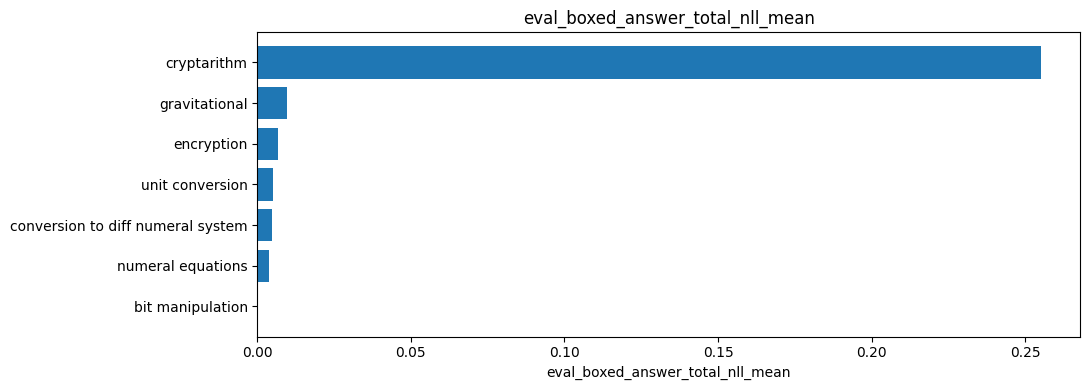

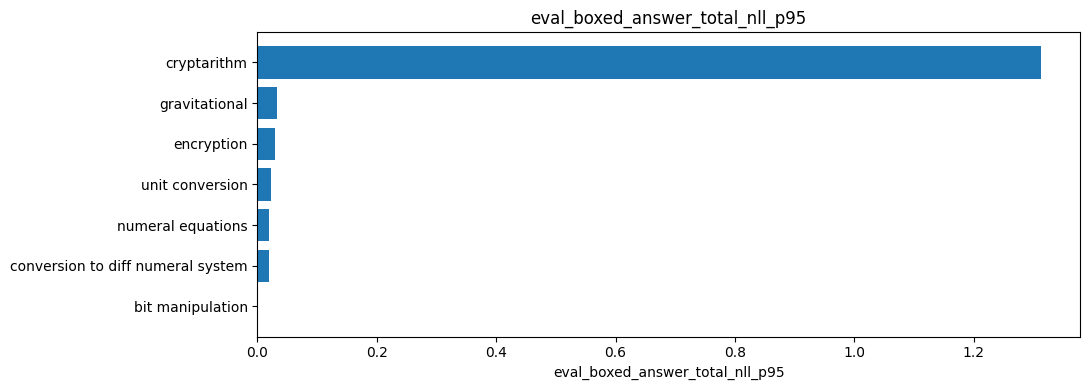

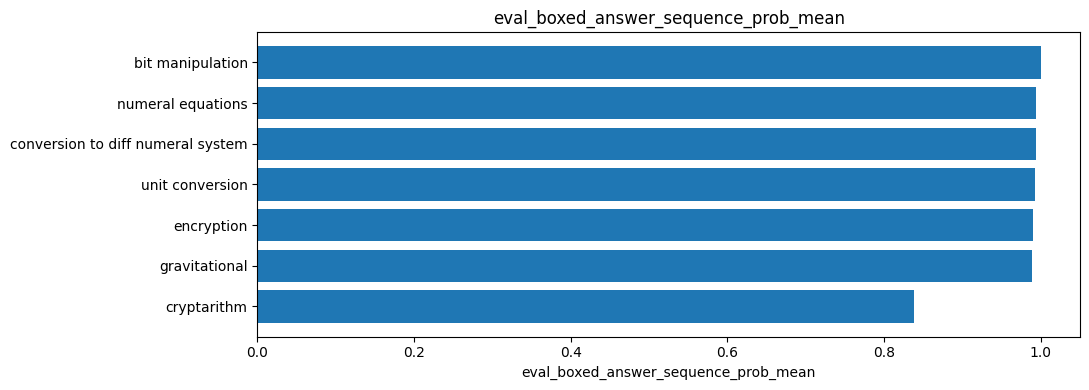

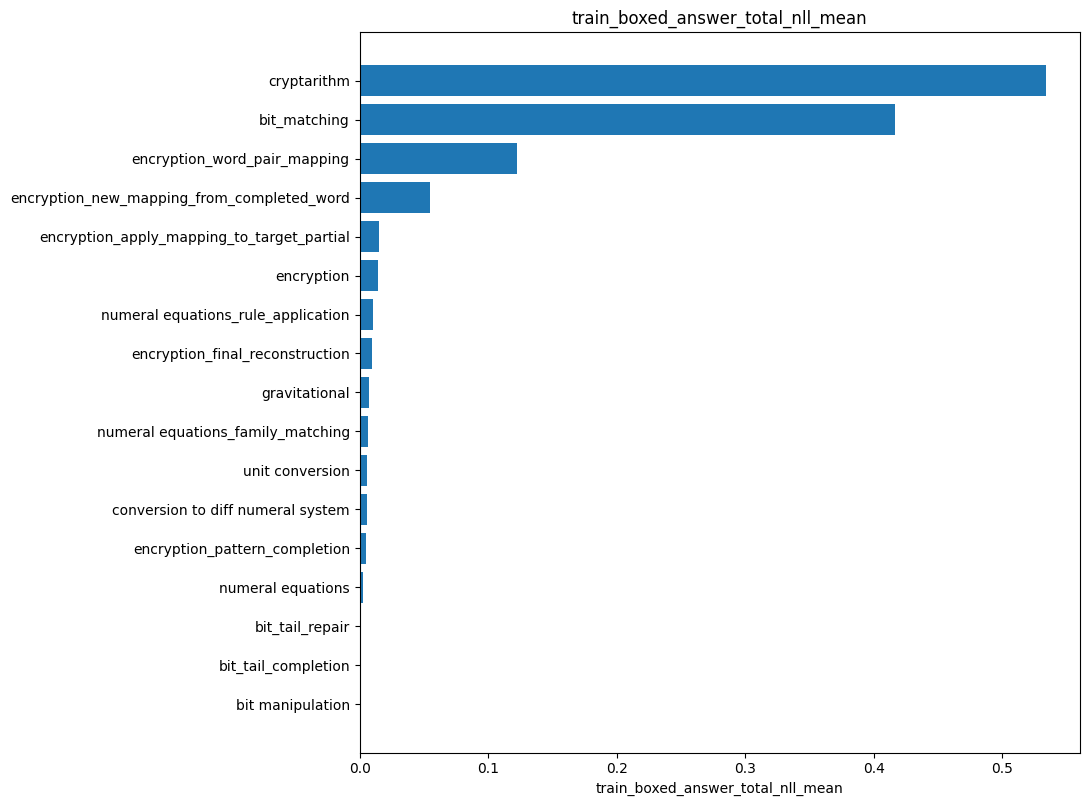

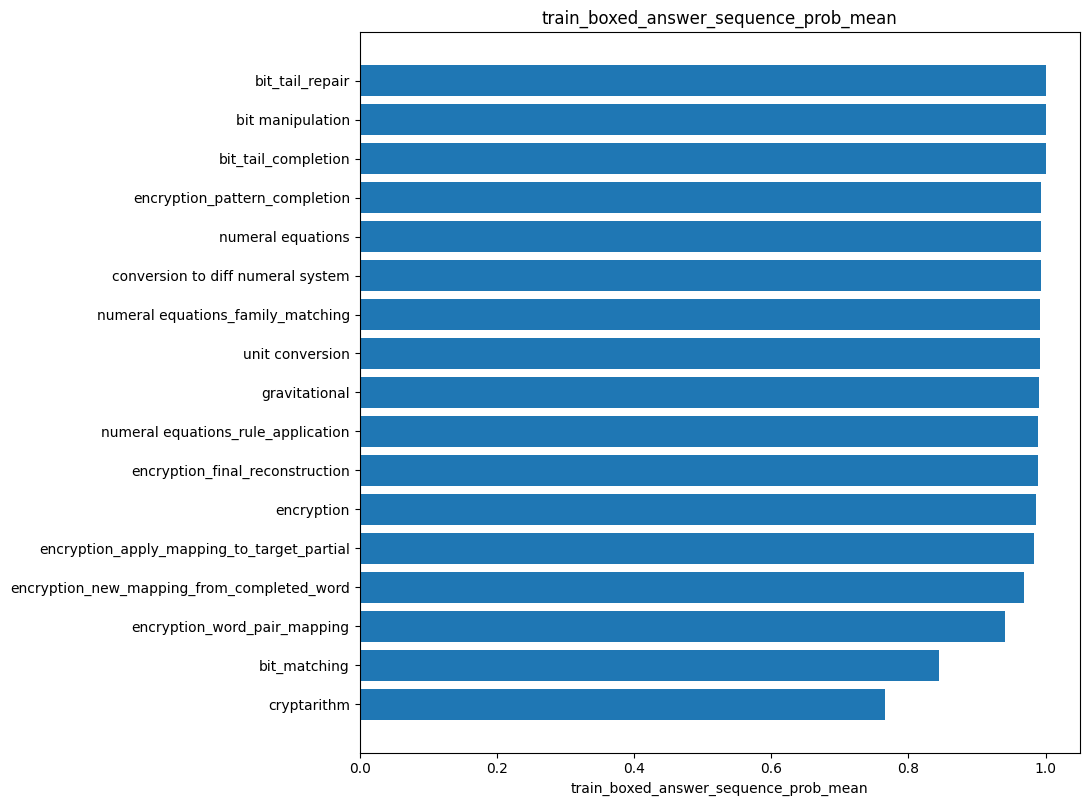

In [22]:
def plot_boxed_sequence_metric(df: pd.DataFrame, metric: str, title: str):
    if df.empty or metric not in df.columns:
        print("Missing metric:", metric)
        return

    plot_df = df[["label", metric]].dropna().sort_values(metric, ascending=True)

    plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.title(title)
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()

for metric in [
    "eval_boxed_answer_total_nll_mean",
    "eval_boxed_answer_total_nll_p95",
    "eval_boxed_answer_sequence_prob_mean",
    "train_boxed_answer_total_nll_mean",
    "train_boxed_answer_sequence_prob_mean",
]:
    plot_boxed_sequence_metric(boxed_seq_cmp, metric, metric)


### Как использовать для bit manipulation

Если `bit manipulation` имеет:

```text
eval_boxed_answer_mean_nll умеренный,
но eval_boxed_answer_total_nll высокий,
и eval_boxed_answer_sequence_prob_est низкий
```

значит модель может быть уверена в большинстве битов, но иногда ошибается в 1–2 битах. Для exact match это всё равно wrong answer.

В таком случае dense dataset должен усиливать bit manipulation даже если обычный `mean_nll` не выглядит страшным.


## 12. Hard examples

In [23]:
hard_train = train["hard_examples"].copy()
hard_eval = eval_["hard_examples"].copy()

if not hard_train.empty:
    print("Train hard examples")
    display(hard_train.head(100))

if not hard_eval.empty:
    print("Eval hard examples")
    display(hard_eval.head(100))


Train hard examples


,id,source,label,source_row_index,checkpoint_bucket,step,difficulty_score,answer_score,cot_score,format_score,mean_nll,p05_logprob,min_logprob,hard_token_ratio,near_zero_token_ratio,cot_mean_nll,final_answer_mean_nll,boxed_answer_mean_nll,format_mean_nll,top_bad_tokens_short,prompt,answer,computed_answer,is_correct
0,gen_5d6066e5dc99d987b668f86c,generated,cryptarithm,6226,320,1,5.425014,0.211533,0.0,4.888689,3.824542,-11.125646,-22.842968,0.663717,0.106195,NaN,1.566973,0.211533,4.158689,format: Target (-22.8430) | Target: &'(-!\nThe target operator is || format: &' (-19.2702) | Target: &'(-!\nThe target operator is '(' || format: concat (-13.0380) | ('.\nLets check if this a concatination\n\nSame-operator examples:\n- || final_answer: F...,"In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n@\`){ = +""|\n""?('' = ""?''\n!''%: = %:!'\nNow, determine the result for: &'(-!",&'-!,&'-!,True
1,gen_935d5804c74931c3cb403b8b,generated,cryptarithm,12856,320,2,5.056738,0.423496,0.0,4.492783,3.500849,-10.280743,-22.433613,0.686957,0.121739,NaN,1.730058,0.423496,3.745210,format: Target (-22.4336) | Target: <:!|]\nThe target || format: concat (-13.5434) | !'.\nLets check if this a concatination\n\nSame-operator examples:\n- || format: Direct (-12.0662) | <] ! !( = !(<]\n\nDirect concat check fails: at least one output || ...,"In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n!`{{\ = !`{\\n/&[)* = )*/&\n<]!!( = !(<]\nNow, determine the result for: <:!|]",|]<:,|]<:,True
2,gen_ccf37fdf5c17a66d3f9bb036,generated,cryptarithm,15870,320,2,5.009912,0.000000,0.0,3.685835,2.971048,-11.373765,-22.874577,0.561290,0.161290,NaN,1.453170,NaN,3.098423,"format: Target (-22.8746) | Target: ''<}-\nThe target operator || format: Direct (-13.7795) | - &: < (( = ((&:\n\nDirect concat check fails: at least one output || format: "" (-13.4875) | the target: '}-' followed by ""''"" gives ""}-''"".\nFinal || format: ...","In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n[*<&& = &&[*\n%'<'% = '%%'\n&:<(( = ((&:\nNow, determine the result for: ''<}-",}-'',}-'',True
3,gen_e8ab5c9e53e38dcd881b174d,solver,encryption_apply_mapping_to_target_partial,8850,320,2,4.712597,0.056602,0.0,3.098817,2.308081,-11.521091,-21.268837,0.454545,0.311688,NaN,1.527036,0.056602,2.575008,format: Apply (-21.2688) | Apply the known dictionary to the encrypted target ' || format: creates (-12.6222) | gives the partial decryption: 'teacher creates stor?'.\n\nAnswer: teacher creates stor || format: stor (-12.4476) | the partial decryption: ...,"In Alice's Wonderland, secret encryption mappings are used on text.\n\nKnown substitution dictionary:\nb -> e\nd -> h\ne -> r\ng -> i\nh -> o\nj -> w\nl -> m\no -> n\np -> t\nq -> g\nr -> c\nt -> l\nv -> b\nw -> u\nx -> a\ny -> s\nz -> d\n\nEncrypted targe...",teacher creates stor?,teacher creates stor?,True
4,gen_cdd1d725b5e95a2893ca0a9d,solver,encryption_new_mapping_from_completed_word,17077,320,7,4.608943,0.705185,0.0,2.664062,2.038272,-11.393334,-23.178520,0.353846,0.369231,NaN,1.566069,0.505185,2.271905,format: Compare (-23.1785) | Compare the encrypted word 'airriok' || format: newly (-12.1978) | positions in '?ollows'. The newly deduced mappings are: 'a'=' || final_answer: Final (-11.8669) | 'a'='f'.\n</think>\nFinal Answer: \boxed{'a' || format: ? ...,"In Alice's Wonderland, secret encryption mappings are used on text.\n\nEncrypted word: airriok\nPartial decryption: ?ollows\nCompleted word: follows\n\nWhich new encrypted-to-plain letter mappings are deduced from the unknown positions?",'a'='f','a'='f',True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,gen_081218a14d0ebe4cba07de2f,solver,numeral equations_rule_application,11825,320,10,3.402882,0.122988,0.0,2.053942,1.643486,-8.315843,-25.158001,0.308943,0.439024

Eval hard examples


,id,source,label,source_row_index,checkpoint_bucket,step,difficulty_score,answer_score,cot_score,format_score,mean_nll,p05_logprob,min_logprob,hard_token_ratio,near_zero_token_ratio,cot_mean_nll,final_answer_mean_nll,boxed_answer_mean_nll,format_mean_nll,top_bad_tokens_short,prompt,answer,computed_answer,is_correct
0,9cc09b16,solver,unit conversion,87,320,320,0.834847,0.000202,0.0,0.355245,0.232986,-2.327714,-4.635536,0.100000,0.845833,NaN,-0.001448,0.000202,0.248578,"format: 3 (-4.6355) | midpoint ratio 1.76430599.\nCalculation yields || format: 9 (-3.1096) | 1.76432391]\n\nTarget 46.0 || format: 3 (-2.8685) | 6, 1.76432391]\n\nTarget 4 || format: 9 (-2.8479) | 1.76430599.\nCalculation yields 81 || format: 1 (-2.7087)...","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n30.27 m becomes 53.41\n9.1 m becomes 16.06\n39.27 m becomes 69.28\nNow, convert the following measurement: 46.01 m",81.18,81.18,True
1,80fdaa17,solver,unit conversion,469,320,320,0.805416,-0.002244,0.0,0.344138,0.235201,-2.235882,-5.748493,0.087500,0.833333,NaN,0.002845,-0.002244,0.250805,"format: 6 (-5.7485) | .94499106]\n 11.72 || format: 3 (-3.2489) | implies ratio in [0.94380952, 0 || format: 5 (-3.1799) | 5, 13.465764]\nAmbiguity detected || format: 6 (-3.0218) | [0.94409660, 0.94 || format: 6 (-3.0190) | 05, 13.465764]\nAmbiguity","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n5.25 m becomes 4.96\n11.18 m becomes 10.56\n11.72 m becomes 11.07\nNow, convert the following measurement: 14.25 m",13.46,13.46,True
2,4e0c6eef,solver,unit conversion,746,320,320,0.795833,0.002551,0.0,0.283817,0.195097,-2.278492,-4.380487,0.071130,0.857741,NaN,0.004050,0.002551,0.207924,"format: 9 (-4.3805) | 3, 11.119749]\nAmbiguity detected || format: 6 (-3.6618) | 1.00917065, 1.009 || format: 7 (-3.3326) | in [1.00917065, 1.0 || format: 1 (-2.5019) | .00968491.\nCalculation yields 11. || format: 3 (-2.4614) | boundaries: [11.113513, 11.","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n10.3 m becomes 10.40\n12.54 m becomes 12.66\n5.85 m becomes 5.91\nNow, convert the following measurement: 11.01 m",11.11,11.12,False
3,ad59f0c6,solver,unit conversion,187,320,320,0.784717,-0.001202,0.0,0.309833,0.203523,-2.219229,-3.422716,0.087137,0.838174,NaN,0.003286,-0.001202,0.216913,"format: 6 (-3.4227) | .20863226, 1.2088 || format: 9 (-2.6685) | ratio in [1.20799537, 1. || format: 5 (-2.4460) | 1.20871548.\nCalculation yields 3 || format: 1 (-2.3997) | ratio 1.20871548.\nCalculation yields || format: 4 (-2.3764) | 34.530624, 34.535","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n8.63 m becomes 10.43\n36.71 m becomes 44.37\n43.21 m becomes 52.23\nNow, convert the following measurement: 28.57 m",34.53,34.53,True
4,0d0ab01d,solver,unit conversion,559,320,320,0.782659,0.003490,0.0,0.343752,0.230415,-2.163042,-8.893656,0.089202,0.854460,NaN,-0.000181,0.003490,0.247792,"format: 6 (-8.8937) | [1.43983694, 1.44 || format: 3 (-3.5045) | 2 implies ratio in [1.43983694, || format: 8 (-3.2125) | 09 boundaries: [31.809806, 3 || format: 6 (-2.3702) | 31.809806, 31.812 || format: 9 (-2.3195) | boundaries: [31.809806, 31.","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n35.57 m becomes 51.22\n29.73 m becomes 42.81\n21.42 m becomes 30.85\nNow, convert the following measurement: 22.09 m",31.81,31.81,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,6c933298,solver,unit conversion,671,320,320,0.510117,0.002767,0.0,0.227231,0.149991,-1.407681,-2.609779,0.061321,0.882075,NaN,0.001973,0.002767,0.161241,"format: 4 (-2.6098) | 1, 44.474414]\nBoth bounds round to || format: 4 (-2.4073) | [44.467341, 44.47 || format: 1 (-2.3737) | 44.474414]\nBoth bounds round to exactly || format: 4 (-2.3629) | 44.474414]\nBoth bounds round to exactly 4 || format

## 13. Decision helper

In [24]:
def classify_action(row):
    eval_diff = row.get("eval_difficulty_score", np.nan)
    train_diff = row.get("train_difficulty_score", np.nan)
    eval_boxed = row.get("eval_boxed_answer_mean_nll", np.nan)
    train_format = row.get("train_format_mean_nll", np.nan)
    train_easy = row.get("train_easy_examples_ratio", np.nan)
    eval_easy = row.get("eval_easy_examples_ratio", np.nan)

    if pd.notna(eval_boxed) and eval_boxed >= 0.08:
        return "boost_answer"
    if pd.notna(eval_diff) and eval_diff >= 0.10:
        return "boost_generalization"
    if pd.notna(train_diff) and train_diff >= 0.15 and (pd.isna(eval_diff) or eval_diff < 0.06):
        return "inspect_cot_or_format"
    if pd.notna(train_format) and train_format >= 0.10:
        return "inspect_format"
    if pd.notna(train_easy) and train_easy >= 0.70 and (pd.isna(eval_easy) or eval_easy >= 0.50):
        return "downsample"
    return "keep"

if not label_cmp.empty:
    decision_table = label_cmp.copy()
    decision_table["suggested_action"] = decision_table.apply(classify_action, axis=1)
    cols = [
        "label", "suggested_action", "decision_score",
        "train_difficulty_score", "eval_difficulty_score",
        "train_boxed_answer_mean_nll", "eval_boxed_answer_mean_nll",
        "train_format_mean_nll", "eval_format_mean_nll",
        "train_easy_examples_ratio", "eval_easy_examples_ratio",
    ]
    cols = [c for c in cols if c in decision_table.columns]
    display(decision_table[cols])


,label,suggested_action,decision_score,train_difficulty_score,eval_difficulty_score,train_boxed_answer_mean_nll,eval_boxed_answer_mean_nll,train_format_mean_nll,eval_format_mean_nll,train_easy_examples_ratio,eval_easy_examples_ratio
0,unit conversion,boost_generalization,2.901042,0.562431,0.418245,0.001139,0.001061,0.211156,0.147831,0.000000,0.000000
1,cryptarithm,boost_answer,1.410204,0.409932,0.084528,0.222991,0.087483,0.221172,0.061461,0.009091,0.000000
2,bit_tail_repair,inspect_cot_or_format,0.624004,0.624004,NaN,NaN,NaN,0.270711,NaN,0.000000,NaN
3,bit_tail_completion,inspect_cot_or_format,0.445048,0.445048,NaN,NaN,NaN,0.197494,NaN,0.013514,NaN
4,encryption_apply_mapping_to_target_partial,inspect_cot_or_format,0.245224,0.245224,NaN,0.002202,NaN,0.179303,NaN,0.133739,NaN
5,numeral equations_rule_application,inspect_cot_or_format,0.152186,0.152186,NaN,0.004816,NaN,0.077030,NaN,0.893871,NaN
6,numeral equations,downsample,0.150610,0.138090,0.005043,0.000894,0.001217,0.062508,0.002546,0.901961,1.000000
7,encryption_new_mapping_from_completed_word,downsample,0.129113,0.129113,NaN,0.010283,NaN,0.079928,NaN,0.835165,NaN
8,gravitational,keep,0.126150,0.077622,0.022385,0.001415,0.001879,0.054270,0.031216,0.002784,0.000000
9,conversion to diff numeral system,downsample,0.119623,0.104366,0.005357,0.002481,0.002272,0.054891,0.001544,0.925952,1.000000


### Suggested action

| Action | Meaning |
|---|---|
| `boost_answer` | усиливать: проблема в ответе |
| `boost_generalization` | усиливать: плохо на eval |
| `inspect_cot_or_format` | не дублировать вслепую; смотреть bad tokens |
| `inspect_format` | возможно проблема в шаблоне |
| `downsample` | можно резать |
| `keep` | оставить как есть |


## 14. Suggested dense weights

In [25]:
def suggest_weight(row):
    eval_diff = row.get("eval_difficulty_score", np.nan)
    eval_hard = row.get("eval_hard_examples_ratio", np.nan)
    eval_boxed = row.get("eval_boxed_answer_mean_nll", np.nan)
    eval_boxed_total = row.get("eval_boxed_answer_total_nll_mean", np.nan)
    eval_seq_prob = row.get("eval_boxed_answer_sequence_prob_mean", np.nan)

    train_diff = row.get("train_difficulty_score", np.nan)
    train_easy = row.get("train_easy_examples_ratio", np.nan)
    train_format = row.get("train_format_mean_nll", np.nan)

    weight = 1.0

    # Main signal: eval/generalization
    if pd.notna(eval_diff) and eval_diff > 0.20:
        weight *= 4.0
    elif pd.notna(eval_diff) and eval_diff > 0.10:
        weight *= 2.5
    elif pd.notna(eval_diff) and eval_diff > 0.05:
        weight *= 1.5

    if pd.notna(eval_hard) and eval_hard > 0.50:
        weight *= 2.0
    elif pd.notna(eval_hard) and eval_hard > 0.25:
        weight *= 1.5

    # Main exact-match answer signal
    if pd.notna(eval_boxed_total) and eval_boxed_total > 1.6:
        weight *= 2.0
    elif pd.notna(eval_boxed_total) and eval_boxed_total > 0.8:
        weight *= 1.5

    if pd.notna(eval_seq_prob) and eval_seq_prob < 0.20:
        weight *= 1.5
    elif pd.notna(eval_seq_prob) and eval_seq_prob < 0.45:
        weight *= 1.25

    if pd.notna(eval_boxed) and eval_boxed > 0.10:
        weight *= 1.5
    elif pd.notna(eval_boxed) and eval_boxed > 0.08:
        weight *= 1.25

    # Train mean_nll is only auxiliary, not primary.
    # Use it only when eval is missing or weak, and do not let format-only hardness dominate.
    if pd.notna(train_diff) and (pd.isna(eval_diff) or eval_diff < 0.05) and train_diff > 0.15:
        weight *= 1.25

    if pd.notna(train_format) and train_format > 0.20 and (pd.isna(eval_boxed) or eval_boxed < 0.05):
        weight *= 0.7

    if pd.notna(train_easy) and train_easy > 0.80 and (pd.isna(eval_diff) or eval_diff < 0.04):
        weight *= 0.3
    elif pd.notna(train_easy) and train_easy > 0.60 and (pd.isna(eval_diff) or eval_diff < 0.06):
        weight *= 0.5

    return round(float(min(max(weight, 0.1), 8.0)), 2)

if not label_cmp.empty:
    suggested = label_cmp.copy()
    suggested["suggested_label_weight"] = suggested.apply(suggest_weight, axis=1)
    first_cols = [
        "label", "suggested_label_weight", "decision_score",
        "eval_boxed_answer_total_nll_mean",
        "eval_boxed_answer_sequence_prob_mean",
    ]
    first_cols = [c for c in first_cols if c in suggested.columns]
    suggested = suggested[first_cols + [c for c in suggested.columns if c not in first_cols]]
    display(suggested)

    label_weights = dict(zip(suggested["label"], suggested["suggested_label_weight"]))
    print(json.dumps(label_weights, ensure_ascii=False))


,label,suggested_label_weight,decision_score,eval_boxed_answer_total_nll_mean,eval_boxed_answer_sequence_prob_mean,train_count_x,train_unique_ids,train_difficulty_score,train_mean_nll,train_p50_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count_x,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p50_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,train_mean_nll_level,train_hard_token_ratio_level,train_near_zero_level,train_boxed_answer_level,eval_mean_nll_level,eval_hard_token_ratio_level,eval_near_zero_level,eval_boxed_answer_level,train_boxed_answer_num_tokens_mean,train_boxed_answer_total_nll_mean,train_boxed_answer_total_nll_p50,train_boxed_answer_total_nll_p95,train_boxed_answer_sequence_prob_mean,train_boxed_answer_sequence_prob_p50,train_boxed_answer_mean_nll_mean,train_count_y,eval_boxed_answer_num_tokens_mean,eval_boxed_answer_total_nll_p50,eval_boxed_answer_total_nll_p95,eval_boxed_answer_sequence_prob_p50,eval_boxed_answer_mean_nll_mean,eval_count_y
0,unit conversion,5.60,2.901042,0.005197,0.992279,1435,1435,0.562431,0.200074,0.152173,0.390734,0.071689,0.848034,NaN,0.029282,0.001139,0.211156,0.001139,0.0,0.287075,1.000000,0.696167,0.000000,318.0,159.0,0.418245,0.139259,0.139251,0.191263,0.054260,0.879456,NaN,0.002227,0.001061,0.147831,0.001061,0.0,0.205480,1.0000,0.54717,0.000000,very_hard,hard,not_learned,answer_easy,hard,hard,not_learned,answer_easy,4.907317,0.005593,0.005476,0.029150,0.991033,0.994539,0.001139,1435,4.918239,0.005526,0.022980,0.994490,0.001061,318.0
1,cryptarithm,2.81,1.410204,0.255108,0.838305,550,550,0.409932,0.211606,0.077445,1.058369,0.049788,0.860325,NaN,0.089066,0.222991,0.221172,0.275038,0.0,0.273339,0.650909,0.361818,0.009091,16.0,8.0,0.084528,0.057883,0.051725,0.111467,0.015072,0.930642,NaN,0.011304,0.087483,0.061461,0.129150,0.0,0.076843,0.4375,0.12500,0.000000,very_hard,hard,not_learned,answer_very_hard,medium,medium,normal,answer_hard,2.623636,0.533653,0.074815,2.624362,0.765729,0.927915,0.222991,550,3.125000,0.109953,1.312125,0.895881,0.087483,16.0
2,bit_tail_repair,0.88,0.624004,NaN,NaN,137,137,0.624004,0.261020,0.183362,1.041045,0.085126,0.821633,NaN,0.040310,NaN,0.270711,0.000000,0.0,0.359368,0.948905,0.671533,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_hard,very_hard,not_learned,unknown,unknown,unknown,unknown,unknown,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,137,NaN,NaN,NaN,NaN,NaN,NaN
3,bit_tail_completion,1.25,0.445048,NaN,NaN,74,74,0.445048,0.191281,0.116808,0.969022,0.059888,0.855879,NaN,0.029310,NaN,0.197494,0.000000,0.0,0.259462,0.824324,0.378378,0.013514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_hard,hard,not_learned,unknown,unknown,unknown,unknown,unknown,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,74,NaN,NaN,NaN,NaN,NaN,NaN
4,encryption_apply_mapping_to_target_partial,1.25,0.245224,NaN,NaN,987,987,0.245224,0.149330,0.043575,0.634423,0.034423,0.926228,NaN,0.032996,0.002202,0.179303,0.002202,0.0,0.221013,0.434650,0.146910,0.133739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hard,hard,normal,answer_easy,unknown,unknown,unknown,unknown,6.974671,0.014888,0.011005,0.046864,0.982918,0.989055,0.002202,987,NaN,NaN,NaN,NaN,NaN,NaN
5,numeral equations_rule_application,0.38,0.152186,NaN,NaN,1338,1335,0.152186,0.071707,0.001371,0.570820,0.014152,0.966083,NaN,0.033384,0.004816,0.077030,0.004809,0.0,0.092510,0.074738,0.062780,0.893

{"unit conversion": 5.6, "cryptarithm": 2.81, "bit_tail_repair": 0.88, "bit_tail_completion": 1.25, "encryption_apply_mapping_to_target_partial": 1.25, "numeral equations_rule_application": 0.38, "numeral equations": 0.3, "encryption_new_mapping_from_completed_word": 0.3, "gravitational": 1.0, "conversion to diff numeral system": 0.3, "encryption_final_reconstruction": 0.3, "encryption_pattern_completion": 0.3, "bit_matching": 0.3, "encryption": 0.5, "numeral equations_family_matching": 0.3, "encryption_word_pair_mapping": 0.3, "bit manipulation": 0.3}


Не принимай suggested weights как истину. Это стартовая точка.

Перед запуском dense train проверь:
1. не усиливается ли label только из-за `format`;
2. нет ли `is_correct=False` среди hard examples;
3. не раздулся ли датасет слишком сильно;
4. не стало ли слишком много одного label.


## 15. Dense command draft

In [26]:
if "label_weights" in globals():
    label_weights_json = json.dumps(label_weights, ensure_ascii=False)
else:
    label_weights_json = "{}"

cmd = f'''
python -m src.build_dense_dataset \
  --input_path data/generated/train_with_syntetic.csv \
  --output_path data/densed/train_densed.csv \
  --train_telemetry_dir models/sft_v0.0.13/train_telemetry \
  --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry \
  --label_weights '{label_weights_json}' \
  --source_weights '{{"generated": 1.0, "solver": 1.0}}' \
  --source_label_weights '{{}}' \
  --base_weight 1.0 \
  --max_repeat 8 \
  --min_repeat 0 \
  --train_hard_multiplier 1.5 \
  --train_very_hard_multiplier 2.0 \
  --train_easy_multiplier 0.5 \
  --eval_hard_multiplier 2.0 \
  --eval_very_hard_multiplier 3.0 \
  --eval_easy_multiplier 0.7 \
  --hard_boxed_answer_total_nll 0.8 \
  --very_hard_boxed_answer_total_nll 1.6 \
  --easy_boxed_answer_total_nll 0.2 \
  --drop_incorrect \
  --shuffle \
  --seed 31231
'''.strip()

print(cmd)


python -m src.build_dense_dataset   --input_path data/generated/train_with_syntetic.csv   --output_path data/densed/train_densed.csv   --train_telemetry_dir models/sft_v0.0.13/train_telemetry   --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry   --label_weights '{"unit conversion": 5.6, "cryptarithm": 2.81, "bit_tail_repair": 0.88, "bit_tail_completion": 1.25, "encryption_apply_mapping_to_target_partial": 1.25, "numeral equations_rule_application": 0.38, "numeral equations": 0.3, "encryption_new_mapping_from_completed_word": 0.3, "gravitational": 1.0, "conversion to diff numeral system": 0.3, "encryption_final_reconstruction": 0.3, "encryption_pattern_completion": 0.3, "bit_matching": 0.3, "encryption": 0.5, "numeral equations_family_matching": 0.3, "encryption_word_pair_mapping": 0.3, "bit manipulation": 0.3}'   --source_weights '{"generated": 1.0, "solver": 1.0}'   --source_label_weights '{}'   --base_weight 1.0   --max_repeat 8   --min_repeat 0   --train_hard_multiplier 1.5   -